### **El pastel que no se reparte - Un retrato de la desigualdad, 1980-2024**

In [4]:
import pandas as pd
import openpyxl
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import statsmodels.formula.api as smf
import statsmodels.api as sm
from plotly.subplots import make_subplots
from scipy import stats
from wildboottest.wildboottest import wildboottest

### **1) Evolución temporal del índice Gini + fotografia actual** 

In [ ]:
# bajado de de Our World in Data, no directamente de WID. El nombre del archivo (con el sufijo "-wid") es justo la pista de que OWID está republicando un indicador que originalmente viene de WID por debajo
# de hecho en el database de WID, entre los indicadores no se encuentra el Gini

df_gini = pd.read_csv('gini-coefficient-before-tax-wid.csv')
df_gini

,Entity,Code,Year,Gini coefficient (before tax)
0,Afghanistan,AFG,2008,0.5245
1,Afghanistan,AFG,2012,0.4927
2,Afghanistan,AFG,2018,0.5154
3,Albania,ALB,1996,0.4659
4,Albania,ALB,2002,0.4799
...,...,...,...,...
3760,Zimbabwe,ZWE,1977,0.6196
3761,Zimbabwe,ZWE,1978,0.6159
3762,Zimbabwe,ZWE,2011,0.6223
3763,Zimbabwe,ZWE,2017,0.6358


In [7]:
# exploración inicial

# Tipos de dato
print("TIPOS DE DATO")
print()
print(df_gini.dtypes)

# Nulos por columna
print()
print("NULOS POR COLUMNA")
print()
print(df_gini.isna().sum())

# Duplicados
print()
print("NÚMERO DE DUPLICADOS")
print()
print(df_gini.duplicated().sum())

# Rango de valores del Gini
print()
print("RANGO DE VALORES DEL GINI")
print()
print(df_gini['Gini coefficient (before tax)'].min(), df_gini['Gini coefficient (before tax)'].max())

TIPOS DE DATO

Entity                            object
Code                              object
Year                               int64
Gini coefficient (before tax)    float64
dtype: object

NULOS POR COLUMNA

Entity                             0
Code                             504
Year                               0
Gini coefficient (before tax)      0
dtype: int64

NÚMERO DE DUPLICADOS

0

RANGO DE VALORES DEL GINI

0.2026 0.8414


In [8]:
# voy a investigar los 504 nulos

# Filas donde Code está vacío
df_sin_code = df_gini[df_gini['Code'].isna()]

# Quiero ver qué entidades son
print(df_sin_code['Entity'].unique())

['East Asia (WID)' 'Europe (WID)' 'Latin America (WID)'
 'Middle East and North Africa (WID)' 'North America (WID)'
 'Oceania (WID)' 'Russia and Central Asia (WID)'
 'South and South-East Asia (WID)' 'Sub-Saharan Africa (WID)']


#### **Exploración inicial del gini-coefficient-before-tax-wid.csv**

**Estructura**: 3765 filas × 4 columnas (Entity, Code, Year, Gini coefficient (before tax))

**Tipos de dato**: correctos, de hecho Year es entero, Gini coefficient es decimal. No requieren conversión.

**Duplicados**: 0 filas duplicadas.

**Rango de valores del Gini**: 0.2026 – 0.8414, coherente con el rango teórico (0-1) y con valores reales de desigualdad.

**Nulos en Code**: 504 valores vacíos.

- Verificado: al filtrar las filas con Code vacío y revisar sus valores de Entity, se confirma que corresponden exactamente a las 9 macrorregiones del dataset (East Asia, Europe, Latin America, Middle East and North Africa, North America, Oceania, Russia and Central Asia, South and South-East Asia, Sub-Saharan Africa).
- Explicación: Code es el código ISO de país. Las macrorregiones no son países, sino agregados construidos por WID combinando varios países - por tanto, no tienen código ISO asignado, y el campo queda vacío en cada una de sus filas (una fila por año).
- Conclusión: estos nulos son estructurales y esperados, no un error de calidad de datos. No requieren limpieza ni imputación.

In [9]:
# hago tabla pivot para explorar más 
# tantos nulos no aparecían antes porque, en la tabla larga, "no hay dato" significa "no hay fila"

tabla_gini = df_gini.pivot(index='Entity', columns='Year', values='Gini coefficient (before tax)')
tabla_gini

Year,1820,1850,1880,1900,1905,1910,1913,1914,1915,1916,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.5154,NaN,NaN,NaN,NaN,NaN,NaN
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.4925,0.5049,0.4978,0.4913,0.4826,0.4823,0.4850,0.4920,NaN,NaN
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.6856,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.5640,0.5630,0.5822,0.6113,0.5714,0.5721,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.5631,NaN,0.5616,NaN,NaN,NaN,NaN,NaN,NaN
World,0.5909,0.6256,0.6713,0.6917,NaN,0.6919,NaN,NaN,NaN,NaN,...,0.6789,0.6778,0.6785,0.6774,0.6752,0.6755,0.6789,0.6789,0.6777,0.6769
Yemen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# investigo las macroregiones que son las que mas me interesan, ya que la intención es trabajar por macrorregiones en el primer grafico

macroregiones_gini = df_gini[df_gini['Entity'].str.contains('WID', na=False)]

tabla_gini_regiones = macroregiones_gini.pivot(index='Entity', columns='Year', values='Gini coefficient (before tax)')
tabla_gini_regiones


Year,1820,1850,1880,1900,1910,1920,1930,1940,1950,1960,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Entity,,,,,,,,,,,,,,,,,,,,,
East Asia (WID),0.5369,0.5484,0.5829,0.6052,0.5990,0.6334,0.6345,0.6370,0.4626,0.5240,...,0.5895,0.5882,0.5921,0.5891,0.5848,0.5881,0.5879,0.5888,0.5886,0.5894
Europe (WID),0.6012,0.6103,0.6140,0.6252,0.6129,0.5609,0.5395,0.5293,0.4839,0.4754,...,0.4948,0.4920,0.4906,0.4886,0.4857,0.4858,0.4856,0.4847,0.4843,0.4838
Latin America (WID),0.6474,0.6544,0.6655,0.6695,0.6912,0.6943,0.6986,0.7145,0.6873,0.6581,...,0.6955,0.6960,0.7006,0.7036,0.6995,0.7165,0.7103,0.7010,0.7004,0.7003
Middle East and North Africa (WID),0.6239,0.6318,0.6385,0.6507,0.6759,0.6835,0.6804,0.6819,0.6464,0.6788,...,0.6721,0.6719,0.6784,0.6815,0.6819,0.6782,0.6783,0.6841,0.6884,0.6860
North America (WID),0.5231,0.5706,0.5234,0.5330,0.5277,0.5399,0.5577,0.5658,0.4834,0.4586,...,0.5783,0.5783,0.5747,0.5772,0.5748,0.5700,0.5792,0.5837,0.5825,0.5825
Oceania (WID),0.5502,0.5654,0.5573,0.5905,0.6132,0.5328,0.5294,0.5172,0.5176,0.4789,...,0.5763,0.5703,0.5736,0.5677,0.5712,0.5783,0.5916,0.5883,0.5887,0.5882
Russia and Central Asia (WID),0.5389,0.5426,0.5497,0.5598,0.5570,0.3200,0.3185,0.3480,0.3726,0.3679,...,0.5795,0.5820,0.5793,0.5814,0.5823,0.6038,0.6073,0.6093,0.6075,0.6056
South and South-East Asia (WID),0.5666,0.5716,0.5997,0.5959,0.5461,0.5928,0.5697,0.6055,0.5058,0.5394,...,0.6448,0.6457,0.6430,0.6452,0.6431,0.6385,0.6397,0.6428,0.6433,0.6427
Sub-Saharan Africa (WID),0.6129,0.6200,0.6607,0.6388,0.6599,0.6635,0.6816,0.6951,0.7012,0.7286,...,0.6812,0.6776,0.6739,0.6692,0.6651,0.6607,0.6610,0.6588,0.6576,0.6604


In [11]:
# trato de averiguar a partir de que año tenemos datos anuales

tabla_gini_regiones.columns

Index([1820, 1850, 1880, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int64', name='Year')

In [12]:
# los datos anuales completos (sin saltos) empiezan exactamente en 1980
# filtro la tabla para quedarme solo con las columnas desde 1980 en adelante

tabla_gini_regiones_1980 = tabla_gini_regiones.loc[:, tabla_gini_regiones.columns >= 1980]
tabla_gini_regiones_1980

Year,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Entity,,,,,,,,,,,,,,,,,,,,,
East Asia (WID),0.6582,0.6573,0.6528,0.6496,0.6456,0.6454,0.6482,0.6493,0.6576,0.6674,...,0.5895,0.5882,0.5921,0.5891,0.5848,0.5881,0.5879,0.5888,0.5886,0.5894
Europe (WID),0.4334,0.4338,0.4339,0.4325,0.4345,0.4371,0.4405,0.4431,0.4480,0.4551,...,0.4948,0.4920,0.4906,0.4886,0.4857,0.4858,0.4856,0.4847,0.4843,0.4838
Latin America (WID),0.7117,0.7108,0.7104,0.7101,0.7110,0.7118,0.7083,0.7080,0.7091,0.7072,...,0.6955,0.6960,0.7006,0.7036,0.6995,0.7165,0.7103,0.7010,0.7004,0.7003
Middle East and North Africa (WID),0.7624,0.7573,0.7361,0.7240,0.7187,0.7109,0.7174,0.7098,0.7112,0.7090,...,0.6721,0.6719,0.6784,0.6815,0.6819,0.6782,0.6783,0.6841,0.6884,0.6860
North America (WID),0.4510,0.4570,0.4636,0.4748,0.4831,0.4851,0.4867,0.4947,0.5087,0.5053,...,0.5783,0.5783,0.5747,0.5772,0.5748,0.5700,0.5792,0.5837,0.5825,0.5825
Oceania (WID),0.4926,0.4926,0.4972,0.4979,0.4980,0.4994,0.5037,0.5151,0.5255,0.5153,...,0.5763,0.5703,0.5736,0.5677,0.5712,0.5783,0.5916,0.5883,0.5887,0.5882
Russia and Central Asia (WID),0.3675,0.3692,0.3711,0.3737,0.3745,0.3770,0.3805,0.3815,0.3809,0.3850,...,0.5795,0.5820,0.5793,0.5814,0.5823,0.6038,0.6073,0.6093,0.6075,0.6056
South and South-East Asia (WID),0.5662,0.5621,0.5607,0.5780,0.5698,0.5733,0.5739,0.5758,0.5813,0.5841,...,0.6448,0.6457,0.6430,0.6452,0.6431,0.6385,0.6397,0.6428,0.6433,0.6427
Sub-Saharan Africa (WID),0.7087,0.7090,0.7084,0.7070,0.7084,0.7046,0.6996,0.6999,0.7017,0.7014,...,0.6812,0.6776,0.6739,0.6692,0.6651,0.6607,0.6610,0.6588,0.6576,0.6604


In [13]:
# para que los años pasen a ser filas en vez de columnas y las macroregiones queden como columnas

tabla_gini_regiones_1980.T

Entity,East Asia (WID),Europe (WID),Latin America (WID),Middle East and North Africa (WID),North America (WID),Oceania (WID),Russia and Central Asia (WID),South and South-East Asia (WID),Sub-Saharan Africa (WID)
Year,,,,,,,,,
1980,0.6582,0.4334,0.7117,0.7624,0.4510,0.4926,0.3675,0.5662,0.7087
1981,0.6573,0.4338,0.7108,0.7573,0.4570,0.4926,0.3692,0.5621,0.7090
1982,0.6528,0.4339,0.7104,0.7361,0.4636,0.4972,0.3711,0.5607,0.7084
1983,0.6496,0.4325,0.7101,0.7240,0.4748,0.4979,0.3737,0.5780,0.7070
1984,0.6456,0.4345,0.7110,0.7187,0.4831,0.4980,0.3745,0.5698,0.7084
1985,0.6454,0.4371,0.7118,0.7109,0.4851,0.4994,0.3770,0.5733,0.7046
1986,0.6482,0.4405,0.7083,0.7174,0.4867,0.5037,0.3805,0.5739,0.6996
1987,0.6493,0.4431,0.7080,0.7098,0.4947,0.5151,0.3815,0.5758,0.6999
1988,0.6576,0.4480,0.7091,0.7112,0.5087,0.5255,0.3809,0.5813,0.7017


In [65]:
# grafico Gini a nivel mundial, linea que se va dibujando

world = df_gini[df_gini['Entity'] == 'World']
world = world[world['Year'] >= 1980]
years_w = sorted(world['Year'].tolist())
valores_w = world.set_index('Year')['Gini coefficient (before tax)']

fig_world_anim = go.Figure(
    data=[go.Scatter(x=[years_w[0]], y=[valores_w[years_w[0]]], mode='lines', line=dict(color='#333333', width=3))]
)

frames_w = []
for year in years_w:
    x_vals = [y for y in years_w if y <= year]
    frames_w.append(go.Frame(
        data=[go.Scatter(x=x_vals, y=valores_w.loc[x_vals], mode='lines', line=dict(color='#333333', width=3))],
        name=str(year)
    ))
fig_world_anim.frames = frames_w

fig_world_anim.update_layout(
    title='Evolución del Gini de ingreso mundial (1980-2024)',
    xaxis=dict(title='Año', range=[1979, 2024], automargin=True),
    yaxis=dict(title='Coeficiente de Gini (before tax)', range=[0.67, 0.72], automargin=True),
    template='plotly_white', width=1000, height=600, margin=dict(l=100, b=100),
    updatemenus=[dict(type='buttons', showactive=False,
        buttons=[dict(label='Play', method='animate',
                       args=[None, dict(frame=dict(duration=100, redraw=True), fromcurrent=True)])])],
    sliders=[dict(steps=[dict(method='animate', args=[[str(y)], dict(frame=dict(duration=0, redraw=True), mode='immediate')], label=str(y)) for y in years_w], active=0)]
)

fig_world_anim.show()

#### **¿Qué pudo causar esa bajada después del año 2000?**

**Causas de la bajada después del año 2000**: investigando vi que la causa principal no es que la desigualdad haya bajado "en todas partes" - es que China e India crecieron muy rápido, y eso hizo que sus ingresos promedio se acercaran a los de los países ricos, reduciendo la brecha entre países (importante recordar que los ingresos promedio pesan mucho en el cálculo del Gini mundial). 

Matiz importante que contradice la lectura simple de "la desigualdad ha mejorado": mientras la desigualdad de ingreso ha caído fuertemente a nivel mundial gracias al rápido crecimiento económico de países emergentes como China e India, ha aumentado en países desarrollados como Estados Unidos, Alemania e incluso Francia. Resumiendo: la desigualdad entre países se redujo gracias al ascenso de China e India, mientras que la desigualdad dentro de muchos países ricos siguió subiendo.

Resumiendo: la caída no significa que la desigualdad haya mejorado "en general". Es principalmente el efecto de que China e India crecieron muy rápido, acercando sus ingresos promedio a los de los países ricos - eso reduce la desigualdad entre países, que pesa mucho en el Gini mundial. Si se excluye el efecto de China e India, la desigualdad global en realidad siguió subiendo hasta el año 2000. Al mismo tiempo, dentro de muchos países ricos (EE.UU., Alemania, Francia), la desigualdad aumentó, no bajó.

Fuentes:
- https://www.bruegel.org/blog-post/global-income-inequality-declining-largely-thanks-china-and-india
- https://www.caixabankresearch.com/en/economics-markets/labour-market-demographics/inequality-analysis-over-time
- https://www.brookings.edu/wp-content/uploads/2017/12/global-inequality.pdf


Quiero verificar la evolución en el tiempo (por ejemplo, 1980-2024) del PIB per cápita de China/India comparado con el del resto del mundo - aunque esto no estará en la presentación final, quiero comprobarlo.

In [66]:
df_pib_china_india = pd.read_csv('pib_per_capita_china_india_world.csv', sep=';', skiprows=1)
df_pib_china_india.columns = [c.strip() for c in df_pib_china_india.columns]
df_pib_china_india['Country'] = df_pib_china_india['Country'].str.strip()
df_pib_china_india.head()

,Country,Variable,Percentile,Year,Value,Data quality
0,China,agdpro_pall_992_i_CN\nProducto bruto interno\n...,pall,1980,3617.0335,5
1,China,agdpro_pall_992_i_CN\nProducto bruto interno\n...,pall,1981,3743.4902,5
2,China,agdpro_pall_992_i_CN\nProducto bruto interno\n...,pall,1982,3958.3253,5
3,China,agdpro_pall_992_i_CN\nProducto bruto interno\n...,pall,1983,4091.3198,5
4,China,agdpro_pall_992_i_CN\nProducto bruto interno\n...,pall,1984,4396.4475,5


In [67]:
tabla_pib_china_india = df_pib_china_india.pivot_table(index='Year', columns='Country', values='Value')
tabla_pib_china_india

Country,China,India,World (PPP)
Year,,,
1980,3617.0335,3672.0553,24873.3
1981,3743.4902,3795.0385,21820.6
1982,3958.3253,3844.0860,21477.9
1983,4091.3198,3983.4266,21494.3
1984,4396.4475,4057.3426,21840.5
1985,4654.0729,4147.5519,22014.7
1986,4781.8548,4240.1338,22185.8
1987,5004.8180,4306.0458,22427.0
1988,5088.6317,4546.9716,22782.2


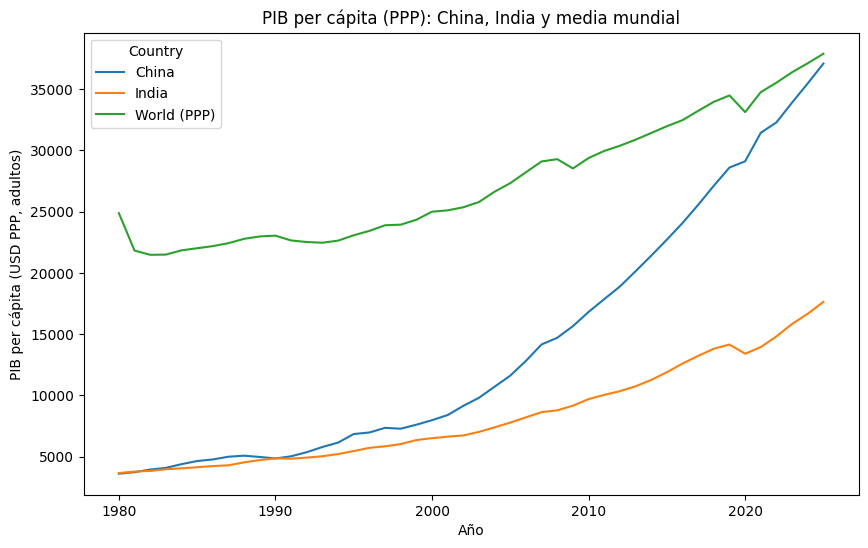

In [68]:
# comparación china, india y world

tabla_pib_china_india.plot(figsize=(10,6))
plt.title('PIB per cápita (PPP): China, India y media mundial')
plt.xlabel('Año')
plt.ylabel('PIB per cápita (USD PPP, adultos)')
plt.show()

#### **Verificación propia: evolución PIB, China/India vs. mundo**

Usando datos propios de WID (PIB per cápita, PPP, adultos, 1980-2025): China parte muy por debajo de la media mundial en 1980 (3,617 vs. 24,873 USD) y prácticamente la alcanza en 2024-2025 (35,465 vs. 37,108 USD). India también converge, aunque más lentamente, quedándose todavía en torno a la mitad de la media mundial (16,673 vs. 37,108 USD en 2024).

Esto confirma con datos propios lo que decián las fuentes externas: la convergencia de ingreso de China e India es un factor clave detrás de la caída del Gini mundial después del año 2000.

#### **Evolución temporal del índice Gini por macroregiones**

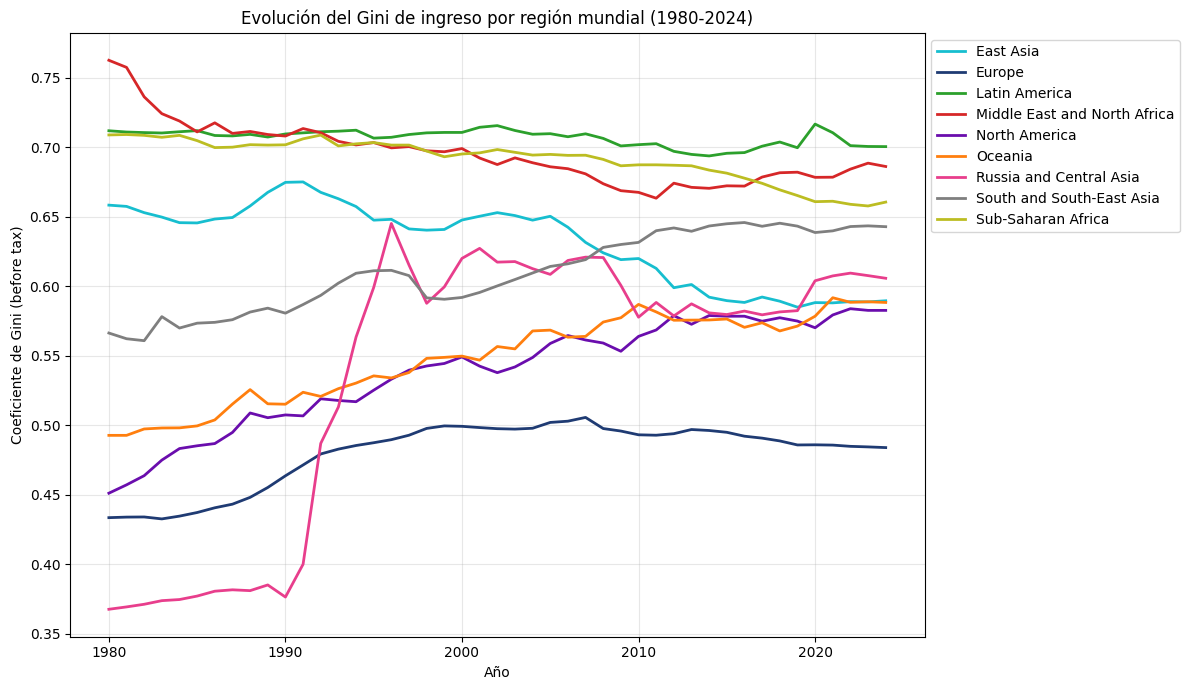

In [69]:
# hago un primer grafico de Evolución del Gini de ingreso por macroregiones

regiones = df_gini[df_gini['Entity'].str.contains('WID', na=False)]
regiones = regiones[regiones['Year']>=1980]

tabla = regiones.pivot(index='Year', columns='Entity', values='Gini coefficient (before tax)')

colores = {
    'Europe (WID)': '#1f3b73',                      # azul oscuro
    'Middle East and North Africa (WID)': '#d62728', # rojo
    'Latin America (WID)': '#2ca02c',                # verde
    'Sub-Saharan Africa (WID)': '#bcbd22',           # amarillo/oliva
    'East Asia (WID)': '#17becf',                    # azul claro/cian
    'South and South-East Asia (WID)': '#7f7f7f',    # gris
    'North America (WID)': '#6a0dad',                # morado intenso
    'Oceania (WID)': '#ff7f0e',                      # naranja
    'Russia and Central Asia (WID)': '#e83e8c',      # rosa/magenta fuerte
}

plt.figure(figsize=(12,7))
for col in tabla.columns:
    plt.plot(tabla.index, tabla[col], label=col.replace(' (WID)',''), linewidth=2, color=colores[col])   # Recorre cada columna (cada región) de la tabla, una por una, y dibuja su línea

plt.title('Evolución del Gini de ingreso por región mundial (1980-2024)')
plt.xlabel('Año')
plt.ylabel('Coeficiente de Gini (before tax)')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
# hago un segundo grafico interactivo: permite hacer zoom, activar/desactivar líneas - el gráfico completo se ve de golpe, con todos los años ya dibujados

fig = go.Figure()

for col in tabla.columns:
    fig.add_trace(go.Scatter(
        x=tabla.index,
        y=tabla[col],
        mode='lines',
        name=col.replace(' (WID)', ''),
        line=dict(color=colores[col], width=2)
    ))

fig.update_layout(
    title='Evolución del Gini de ingreso por región mundial (1980-2024)',
    xaxis_title='Año',
    yaxis_title='Coeficiente de Gini (before tax)',
    legend_title='Región',
    hovermode='x unified',
    template='plotly_white',
    width=1200,
    height=800
)

fig.show()

In [ ]:
# grafico dinamico

regiones = df_gini[df_gini['Entity'].str.contains('WID', na=False)].copy()
regiones = regiones[regiones['Year'] >= 1980]
regiones['Entity'] = regiones['Entity'].str.replace(' (WID)', '', regex=False)

colores = {
    'Europe': '#1f3b73',
    'Middle East and North Africa': '#d62728',
    'Latin America': '#2ca02c',
    'Sub-Saharan Africa': '#bcbd22',
    'East Asia': '#17becf',
    'South and South-East Asia': '#7f7f7f',
    'North America': '#6a0dad',
    'Oceania': '#ff7f0e',
    'Russia and Central Asia': '#e83e8c',
}

orden_1980 = regiones[regiones['Year'] == 1980].sort_values('Gini coefficient (before tax)', ascending=False)['Entity'].tolist()

fig = px.bar(
    regiones.sort_values('Year'),
    x='Gini coefficient (before tax)',
    y='Entity',
    color='Entity',
    color_discrete_map=colores,
    animation_frame='Year',
    range_x=[0, 0.8],
    category_orders={'Entity': orden_1980}
)
fig.update_layout(xaxis_title='Gini (antes de impuestos)')
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 100
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 50

fig.show()

#### **Punto 1: gráfico dinámico del índice Gini y su evolución temporal (1980-2024)**

El coeficiente de Gini es un número entre 0 y 1, donde 0 se corresponde con la perfecta igualdad (todos tienen los mismos ingresos) y 1 se corresponde con la perfecta desigualdad (una persona tiene todos los ingresos y los demás ninguno).

**El caso más llamativo**: Rusia y Asia Central pasa de ser la región más igualitaria del grupo en 1980 (Gini ~0.36) a una de las más altas para mediados de los 90 (~0.65) - un cambio abrupto y sostenido, no gradual. Encaja con la transición desde la URSS hacia economía de mercado a inicios de los 90. Es el patrón más fuerte de todo el gráfico.

**Europa se mantiene aparte**: es la única región que se queda consistentemente por debajo de las demás durante todo el período (0.44-0.50), sin acercarse nunca al resto. 

**Latino America y MENA empiezan altas y se mantienen altas**: a diferencia de otras regiones que fluctúan, estas dos parten ya con Gini alto (~0.70+) en 1980 y no bajan mucho - sugiere una desigualdad más estructural/histórica que coyuntural.

**East Asia**: es la única región con caída sostenida, pasa de un pico de 0.6746 en 1990 a 0.5894 en 2024 - una bajada de casi 9 puntos, la más grande de todas las regiones en sentido descendente. Es un patrón similar al que ya vimos con el Gini mundial (la explicación de China/India) - probable hipótesis: dado que China pesa mucho en esta macrorregión, su fuerte crecimiento económico podría estar "arrastrando hacia abajo" el Gini de toda la región, por el mismo mecanismo de convergencia entre países dentro del bloque. no es que China sea más igualitaria por dentro, es que el ingreso promedio de China converge con el de otros países de la región (Japón, Corea del Sur, etc.), reduciendo la brecha entre países dentro de la macrorregión "East Asia (WID)".

**Middle East and North Africa** - caída marcada solo al principio: baja de 0.7624 (1980) a ~0.71 (mediados de los 80), y después se estabiliza casi plana el resto del período (0.66-0.69) - a diferencia de Rusia (que sube de golpe) o de Latam (que se mantiene plana desde el principio), aquí el cambio ocurre temprano y luego se congela.

**North America**: pasa de 0.4510 (1980) a 0.5825 (2024) - una subida de casi 0.13 puntos, de las más grandes en sentido ascendente de todo el gráfico. Es un aumento constante y sostenido, sin caídas relevantes en ningún tramo.

**Convergencia hacia el final**: en los últimos años (2015-2024), varias regiones que empezaron muy distintas (North America, Oceania, Russia) terminan agrupadas en una banda similar (0.55-0.60) - es un dato interesante en sí mismo: la dispersión entre regiones parece reducirse en el período reciente, aunque el nivel general de desigualdad sigue siendo alto en todas.


#### **El porqué del caso más llamativo**

**El porqué del caso más llamativo**: el rango de años coincide con la disolución de la Unión Soviética (1991) y la transición de las economías de esa macroregión desde un sistema centralizado/planificado hacia una economía de mercado. En un sistema centralizado, los ingresos tienden a estar mucho más comprimidos (menos diferencia entre quien más y quien menos gana) porque el Estado controla salarios, precios y propiedad. Al pasar a mercado, aparecen de golpe fenómenos como la privatización de empresas estatales, la aparición de nuevos ricos vinculados a esas privatizaciones, y salarios que empiezan a variar mucho más según sector y habilidad - todo eso empuja la desigualdad hacia arriba muy rápido. 

**Fuentes**: Un estudio publicado en CEPR (basado en trabajo de Piketty y coautores, el mismo marco teórico de este trabajo) señala que la riqueza nacional neta de Rusia en 1990 rondaba el 400% del ingreso nacional, con cerca del 75% en manos públicas y algo más del 100% en manos privadas - es decir, antes de la transición había muy poca propiedad privada. Dicho de otra forma: La riqueza total de Rusia en 1990 equivalía a cuatro años enteros de ingreso nacional (400%). De ese total, tres cuartas partes (300%, tres años de ingreso) estaban en manos del Estado, y solo una cuarta parte (100%, un año de ingreso) era propiedad privada - es decir, antes de la transición había muy poca propiedad privada.

No es solo "menos intervención = más desigualdad" en plan genérico, es también: la propiedad que antes era pública y estaba muy repartida (en el sentido de "de nadie en particular") pasa a manos de unos pocos particulares de golpe, y eso es lo que dispara la desigualdad tan rápido.

El Parlamento Europeo describe el proceso de esta forma: en la Unión Soviética, el ingreso promedio del 1% más rico era solo 4-5 veces mayor que el de la sociedad en general; esta situación relativamente igualitaria cambió drásticamente a inicios de los 90, cuando las reformas económicas adoptadas transformaron la economía planificada en un mercado capitalista, y un programa de privatización mal gestionado creó una nueva clase de oligarcas. Un artículo académico en ScienceDirect confirma todo esto: se acepta generalmente que la desigualdad era baja en la Unión Soviética antes de 1990, aproximadamente al mismo nivel que en los países escandinavos; para 1994, el coeficiente de Gini nacional de Rusia se estimaba en 0.45 (importante: este último dato es específicamente de Rusia como país.)

Fuentes:
- https://cepr.org/voxeu/columns/soviets-oligarchs-inequality-and-property-russia-1905-2016
- https://www.europarl.europa.eu/RegData/etudes/ATAG/2018/620225/EPRS_ATA(2018)620225_EN.pdf
- https://www.sciencedirect.com/science/article/abs/pii/S0176268016302130

**Importante**: el Gini de Rusia de mi propio dataset es = 0.5366 en 1994, el valor de 0.45 es de ScienceDirect - la fuente externa queda como apoyo narrativo del patrón general (contexto histórico de la transición).

#### **Siguiente punto: fotografia actual, distribución de ingresos VS riqueza es decir porcentaje de ingreso mundial o riqueza por grupo, 2024**

In [15]:
# subo dataset ingresos

df_ingreso = pd.read_csv('WID_Data_06082026-141303.csv', sep=';', skiprows=1)
df_ingreso.columns = [c.strip() for c in df_ingreso.columns]
df_ingreso

,Country,Variable,Percentile,Year,Value,Data quality
0,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1980,0.2070,0
1,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1981,0.2050,0
2,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1982,0.2029,0
3,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1983,0.2008,0
4,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1984,0.2005,0
...,...,...,...,...,...,...
3955,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2020,0.3865,0
3956,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2021,0.3842,0
3957,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2022,0.3834,0
3958,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2023,0.3843,0


In [16]:
# exploración inicial

# Tipos de dato
print("TIPOS DE DATO")
print()
print(df_ingreso.dtypes)

# Nulos por columna
print()
print("NULOS POR COLUMNA")
print()
print(df_ingreso.isna().sum())

# Duplicados
print()
print("NÚMERO DE DUPLICADOS")
print()
print(df_ingreso.duplicated().sum())

TIPOS DE DATO

Country          object
Variable         object
Percentile       object
Year              int64
Value           float64
Data quality      int64
dtype: object

NULOS POR COLUMNA

Country         0
Variable        0
Percentile      0
Year            0
Value           0
Data quality    0
dtype: int64

NÚMERO DE DUPLICADOS

0


In [17]:
# voy a investigar que tipo de informaciones contiene exactamente la columna variable, tomando como ejemplo la primera fila

print(df_ingreso['Variable'].iloc[0])

sptinc_p99p100_992_j_QL-PPP
Pre-tax national income
Top 1% | participación | adultos | división en partes iguales



Son tres líneas de información junta en una sola celda:
- Código técnico de WID: sptinc_p99p100_992_j_QL-PPP
- Nombre del indicador: Pre-tax national income
- Detalle de la configuración: Top 1% | participación | adultos | división en partes iguales

Decido conservar la columna Variable por trazabilidad: contiene el código técnico de WID (ej. 'sptinc_p99p100_992_j_QL-PPP') que permite verificar o reproducir el origen exacto de cada dato, aunque dicha información sea parcialmente redundante con Percentile.

In [18]:
# voy a traducir los códigos de Percentile a nombres claros y legibles 

mapeo_percentil = {
    'p0p50': '50% Inferior',
    'p50p90': 'Middle 40%',
    'p90p100': 'Top 10%',
    'p99p100': 'Top 1%'
}

df_ingreso['Percentile'] = df_ingreso['Percentile'].map(mapeo_percentil)
df_ingreso

,Country,Variable,Percentile,Year,Value,Data quality
0,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1980,0.2070,0
1,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1981,0.2050,0
2,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1982,0.2029,0
3,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1983,0.2008,0
4,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1984,0.2005,0
...,...,...,...,...,...,...
3955,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2020,0.3865,0
3956,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2021,0.3842,0
3957,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2022,0.3834,0
3958,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2023,0.3843,0


**Nota sobre Pre-tax national income (Ingreso nacional antes de impuestos)**

Es el ingreso total generado por la economía de un país o región, antes de que se apliquen impuestos y transferencias - incluye tanto el ingreso que va al **trabajo** (sueldos, salarios) como el que va al **capital** (beneficios, dividendos, rentas).
En este dataset, la variable se descarga en modo **"participación"**: en vez de un valor monetario, muestra qué **porcentaje** de ese ingreso total se lleva cada grupo de población: 50% Inferior, Middle 40%, Top 10%, Top 1%.

Es la misma variable base (aptinc_pall_992 / sptinc) que usaré más adelante en modo "Promedio" para calcular el ingreso laboral por región (national_income × labor_share), pero aquí en modo participación sirve para un propósito distinto: mostrar cómo se reparte el ingreso entre grupos, no su valor absoluto.

In [19]:
# subo dataset riqueza

df_riqueza = pd.read_csv('wid_riqueza_1950_2025.csv', sep=';', skiprows=1)
df_riqueza.columns = [c.strip() for c in df_riqueza.columns]                                  # quita espacios sobrantes que traía el archivo original
df_riqueza

,Country,Variable,Percentile,Year,Value,Data quality
0,World (PPP),anweal_pall_992_i_WO-PPP\nRiqueza nacional a v...,pall,1950,17490.8213,4.0
1,World (PPP),anweal_pall_992_i_WO-PPP\nRiqueza nacional a v...,pall,1951,18266.5941,4.0
2,World (PPP),anweal_pall_992_i_WO-PPP\nRiqueza nacional a v...,pall,1952,18939.1746,4.0
3,World (PPP),anweal_pall_992_i_WO-PPP\nRiqueza nacional a v...,pall,1953,19698.8108,4.0
4,World (PPP),anweal_pall_992_i_WO-PPP\nRiqueza nacional a v...,pall,1954,20216.6706,4.0
...,...,...,...,...,...,...
375,World (PPP),shweal_p99p100_z_WO-PPP\nRiqueza de los hogare...,p99p100,2021,0.3717,0.0
376,World (PPP),shweal_p99p100_z_WO-PPP\nRiqueza de los hogare...,p99p100,2022,0.3664,0.0
377,World (PPP),shweal_p99p100_z_WO-PPP\nRiqueza de los hogare...,p99p100,2023,0.3639,0.0
378,World (PPP),shweal_p99p100_z_WO-PPP\nRiqueza de los hogare...,p99p100,2024,0.3644,0.0


Explicación de las 6 columnas

- Country: país o región agregada (aquí siempre "World (PPP)" = todo el planeta, en dólares ajustados por poder adquisitivo)
- Variable: código del indicador que se está midiendo (ej. participación en la riqueza, riqueza promedio por adulto)
- Percentile: qué grupo de población - pall = toda la población, p0p50 = 50% más pobre, p90p100 = 10% más rico, p99p100 = 1% más rico
- Year: año de la observación
- Value: el valor del indicador para ese grupo y año (puede ser una participación en % o un monto en dólares, según la variable)

Variable: 5 valores posibles, agrupables en 2 tipos:
  - anweal_pall / wnweal_pall: riqueza nacional promedio por adulto, y ratio riqueza/ingreso (valores en dólares o como ratio, aplican a "pall" = toda la población, no hay desglose por grupo)
  - shweal_p90p100 / shweal_p0p50 / shweal_p99p100: participación (%) en la riqueza total de los hogares, para el top 10%, bottom 50% y top 1% respectivamente

Percentile: el grupo de población al que corresponde esa fila
  - pall = toda la población (sin distinguir grupos)
  - p0p50 = el 50% más pobre
  - p90p100 = el 10% más rico
  - p99p100 = el 1% más rico

Year: año de la observación (2025 aparece con Value = NaN porque el año todavía no tiene dato completo)

Value: el número medido - su significado cambia según la Variable:
  - si es "anweal": dólares PPP de riqueza promedio por adulto
  - si es "wnweal": un ratio (riqueza total / ingreso total)
  - si es "shweal": una proporción entre 0 y 1 (ej. 0.3717 = 37.17% de la riqueza total)

Data quality: puntaje 0-5 de calidad del dato; en el dataset solo aparecen 0, 4 o NaN, y su significado exacto (qué distingue un 0 de un 4) no está documentado públicamente de forma clara 

#### **Nota sobre "Data quality" (0-5): investigación en la fuente oficial**

**Fuente oficial verificada**: Distributional National Accounts Guidelines 2025, WID.world, Capítulo 9.1 "Series Quality Grades" - https://wid.world/document/distributional-national-accounts-dina-guidelines-2025-methods-and-concepts-used-in-the-world-inequality-database/

**Qué dice el documento oficial**: dada la heterogeneidad en la calidad de los datos disponibles en el mundo, la calidad de las estimaciones de WID varía mucho. WID le pone a cada serie una nota simple del 0 al 5, basada en "consideraciones amplias" sobre las fuentes que usa esa serie, visible directamente en su web. Para el detalle preciso, remiten a los papers específicos de cada país o región. Además, publican un índice de transparencia por país para animar a los gobiernos a publicar mejores datos, y dan ejemplos del mínimo de tabulaciones fiscales que cada administración debería publicar.

**Qué significa "revisar el paper específico de cada país"**: WID no usa una fórmula genérica para asignar la nota de calidad - cada país tiene su propio estudio técnico (escrito por los investigadores que trabajaron con sus datos), donde explican qué fuentes usaron, qué problemas tuvieron, y por qué asignaron esa nota concreta a cada serie. Para saber con exactitud por qué España en 2010 tiene calidad "4" y otro país en otro año tiene "0", habría que consultar el documento técnico propio de cada país - no existe una explicación única y genérica válida para todos a la vez.

**Por qué esto es relevante para el proyecto**: con 216 países en los datos, sería inviable revisar el paper técnico de cada uno solo para entender la escala de calidad. La limitación queda confirmada como honesta y verificada: el significado preciso de "Data quality" (0-5) es oficial y real, pero no está accesible de forma centralizada y práctica para un proyecto de este alcance.

5 variables una por una

- **anweal_pall_992_i_WO-PPP**
Riqueza nacional a valor de mercado, promedio por adulto.
Es un monto en dólares PPP: cuánta riqueza tiene, en promedio, cada adulto en el mundo.
Solo tiene percentil "pall" (no se desglosa por grupo).

- **wnweal_pall_999_i_WO-PPP**
Riqueza nacional a valor de mercado, como ratio.
Es el ratio riqueza/ingreso: cuántas veces el ingreso anual representa la riqueza acumulada.
Solo tiene percentil "pall" (no se desglosa por grupo).

- **shweal_p90p100_z_WO-PPP**
Participación del Top 10% en la riqueza neta de los hogares.
Es un porcentaje: qué proporción de toda la riqueza mundial tiene el 10% más rico.

- **shweal_p0p50_z_WO-PPP**
Participación del 50% inferior en la riqueza neta de los hogares.
Es un porcentaje: qué proporción de toda la riqueza mundial tiene el 50% más pobre.

- **shweal_p99p100_z_WO-PPP**
Participación del Top 1% en la riqueza neta de los hogares.
Es un porcentaje: qué proporción de toda la riqueza mundial tiene el 1% más rico.

In [20]:
# Muestra los valores únicos de cada columna

for col in df_riqueza.columns:
    print(col)
    print(df_riqueza[col].unique())
    print()

Country
['World (PPP) ']

Variable
['anweal_pall_992_i_WO-PPP\nRiqueza nacional a valor de mercado\nPoblación total | promedio | adultos | individuos |  | ppp | constante (2025)\n'
 'wnweal_pall_999_i_WO-PPP\nRiqueza nacional a valor de mercado\nPoblación total | ratio | todas las edades | individuos\n'
 'shweal_p90p100_z_WO-PPP\nRiqueza de los hogares neta\nTop 10% | participación | adultos | división en partes iguales\n'
 'shweal_p0p50_z_WO-PPP\nRiqueza de los hogares neta\n50% Inferior | participación | adultos | división en partes iguales\n'
 'shweal_p99p100_z_WO-PPP\nRiqueza de los hogares neta\nTop 1% | participación | adultos | división en partes iguales\n']

Percentile
['pall' 'p90p100' 'p0p50' 'p99p100']

Year
[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 20

In [21]:
# extrae correctamente el código corto de la primera línea de variable, tal y como están son demasiado largas
df_riqueza['Variable_corta'] = df_riqueza['Variable'].str.split('\n').str[0].str.strip()                         

tabla_limpia = df_riqueza.pivot_table(index='Year', columns=['Variable_corta', 'Percentile'], values='Value')
tabla_limpia

# Diccionario de equivalencias:
# riqueza_promedio_adulto = anweal_pall_992_i_WO-PPP
# bottom_50 = shweal_p0p50_z_WO-PPP (percentil: p0p50)
# top_10 = shweal_p90p100_z_WO-PPP (percentil: p90p100)
# top_1 = shweal_p99p100_z_WO-PPP (percentil: p99p100)
# ratio_riqueza_ingreso = wnweal_pall_999_i_WO-PPP

Variable_corta,anweal_pall_992_i_WO-PPP,shweal_p0p50_z_WO-PPP,shweal_p90p100_z_WO-PPP,shweal_p99p100_z_WO-PPP,wnweal_pall_999_i_WO-PPP
Percentile,pall,p0p50,p90p100,p99p100,pall
Year,,,,,
1950,17490.8213,0.0237,0.7824,0.4399,2.8831
1951,18266.5941,NaN,NaN,NaN,2.8478
1952,18939.1746,NaN,NaN,NaN,2.8704
1953,19698.8108,NaN,NaN,NaN,2.8485
1954,20216.6706,NaN,NaN,NaN,2.9066
...,...,...,...,...,...
2021,125743.3264,0.0212,0.7476,0.3717,6.3468
2022,126707.3132,0.0217,0.7431,0.3664,6.2613


In [22]:
tabla_limpia_riqueza = df_riqueza.pivot_table(index='Year', columns=['Variable_corta', 'Percentile'], values='Value')
tabla_limpia_riqueza.columns = ['riqueza_promedio_adulto', 'pct50_mas_pobre', 'pct10_mas_rico', 'pct1_mas_rico', 'ratio_riqueza_ingreso']
tabla_limpia_riqueza

# riqueza_promedio_adulto = cuánta riqueza tiene, en promedio, un adulto cualquiera del mundo ese año. Ej.: 17490.8213 en 1950 significa que, en promedio, un adulto del mundo tenía 17.490 dólares de patrimonio neto ese año.
# pct50_mas_pobre = un número entre 0 y 1, que representa una proporción = qué fracción de toda la riqueza mundial tiene el 50% más pobre. Ej.:: 0.0237 significa 2.37% - el 50% más pobre del mundo tenía el 2.37% de toda la riqueza mundial ese año.
# pct10_mas_rico = igual que el anterior, proporción entre 0 y 1. Ej.: 0.7824 significa que el 10% más rico tenía el 78.24% de toda la riqueza mundial.
# pct1_mas_rico - igual, proporción entre 0 y 1. Ej.: 0.4399 significa que el 1% más rico tenía el 43.99% de toda la riqueza mundial.
# ratio_riqueza_ingreso = un número que representa cuántos años de ingreso equivalen a la riqueza total acumulada. Ejemplo: 2.8831 significa que la riqueza total del mundo equivalía a 2.88 años de ingreso mundial ese año

,riqueza_promedio_adulto,pct50_mas_pobre,pct10_mas_rico,pct1_mas_rico,ratio_riqueza_ingreso
Year,,,,,
1950,17490.8213,0.0237,0.7824,0.4399,2.8831
1951,18266.5941,NaN,NaN,NaN,2.8478
1952,18939.1746,NaN,NaN,NaN,2.8704
1953,19698.8108,NaN,NaN,NaN,2.8485
1954,20216.6706,NaN,NaN,NaN,2.9066
...,...,...,...,...,...
2021,125743.3264,0.0212,0.7476,0.3717,6.3468
2022,126707.3132,0.0217,0.7431,0.3664,6.2613
2023,127825.6817,0.0223,0.7399,0.3639,6.1655


In [23]:
# Esto quita los espacios sobrantes al principio y al final de cada valor de la columna country

df_ingreso['Country'] = df_ingreso['Country'].str.strip()

In [24]:
# saco los datos para la fotografia de la situacion actual

riqueza_2024 = tabla_limpia_riqueza.loc[2024, ['pct50_mas_pobre', 'pct10_mas_rico', 'pct1_mas_rico']]

ingreso_2024 = df_ingreso[(df_ingreso['Country'] == 'World (PPP)') & (df_ingreso['Year'] == 2024)][['Percentile', 'Value']]

print(riqueza_2024)
print()
print(ingreso_2024)

pct50_mas_pobre    0.0225
pct10_mas_rico     0.7379
pct1_mas_rico      0.3644
Name: 2024, dtype: float64

        Percentile   Value
3824        Top 1%  0.2061
3869       Top 10%  0.5342
3914  50% Inferior  0.0809
3959    Middle 40%  0.3849


In [25]:
# transformo en porcentaje

riqueza_2024_pct = riqueza_2024 * 100

ingreso_2024_pct = ingreso_2024.copy()
ingreso_2024_pct['Value'] = ingreso_2024_pct['Value'] * 100

print(riqueza_2024_pct)
print()
print(ingreso_2024_pct)

# .copy() en ingreso_2024 (no en riqueza_2024) porque aquí se modifica una columna dentro de una tabla y se reasigna - riqueza_2024 es una Serie, la multiplicación ya genera un objeto nuevo sin ese riesgo (evita SettingWithCopyWarning)

pct50_mas_pobre     2.25
pct10_mas_rico     73.79
pct1_mas_rico      36.44
Name: 2024, dtype: float64

        Percentile  Value
3824        Top 1%  20.61
3869       Top 10%  53.42
3914  50% Inferior   8.09
3959    Middle 40%  38.49


In [26]:
# renombro los índices de riqueza_2024_pct para que coincidan con los nombres de grupo de ingreso_final

grupos = {
    'pct50_mas_pobre': '50% Inferior',
    'pct10_mas_rico': 'Top 10%',
    'pct1_mas_rico': 'Top 1%'
}

riqueza_final = riqueza_2024_pct.rename(index=grupos)

ingreso_final = ingreso_2024_pct.set_index('Percentile')['Value']
ingreso_final = ingreso_final[['50% Inferior', 'Top 10%', 'Top 1%']]

comparacion_2024 = pd.DataFrame({
    'Ingreso': ingreso_final,
    'Riqueza': riqueza_final
})

comparacion_2024

,Ingreso,Riqueza
50% Inferior,8.09,2.25
Top 10%,53.42,73.79
Top 1%,20.61,36.44


In [27]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=comparacion_2024.index,
    y=comparacion_2024['Ingreso'],
    name='Ingreso',
    marker_color='#17becf',
    text=comparacion_2024['Ingreso'].apply(lambda x: f'{x:.0f}%'),
    textposition='outside'
))

fig.add_trace(go.Bar(
    x=comparacion_2024.index,
    y=comparacion_2024['Riqueza'],
    name='Riqueza',
    marker_color='#d62728',
    text=comparacion_2024['Riqueza'].apply(lambda x: f'{x:.0f}%'),
    textposition='outside'
))

fig.update_layout(
    title='Ingreso vs. Riqueza por grupo: distribución a nivel mundial (2024)',
    xaxis=dict(title='Grupo', automargin=True),
    yaxis=dict(title='Porcentaje del total mundial (%)', automargin=True),
    barmode='group',
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=100, b=100)
)

fig.show()

#### **Gráfico: Ingreso vs. Riqueza por grupo, mundial (2024)**

Compara, para el mismo grupo social (50% Inferior, Top 10%, Top 1%), su cuota de ingreso frente a su cuota de riqueza. No busca mostrar el pastel completo (por eso no se incluye Middle 40% ni se espera que las barras sumen 100%). El objetivo es evidenciar que la riqueza está sistemáticamente más concentrada que el ingreso en los mismos grupos >>> NOTA: COMPARARÉ ESTE CON OTRO GRAFICO COMPLEMENTARIO QUE ENSEÑE EL PASTEL ENTERO (Middle 40% incluido).

#### **Lectura del gráfico**

En los tres grupos, la riqueza está más concentrada que el ingreso, pero el patrón no es uniforme:

- **50% Inferior**: tiene una cuota de ingreso (8.09%) casi 4 veces mayor que su cuota de riqueza (2.25%). Este grupo depende casi por completo de lo que gana en el momento (salario), porque apenas tiene activos acumulados - coherente con la idea de "vivir al día" sin colchón financiero.

- **Top 10%**: la brecha es la más amplia en términos absolutos - pasa de 53.42% del ingreso a 73.79% de la riqueza, una diferencia de 20.4 puntos porcentuales. Este grupo no solo gana una porción grande del ingreso mundial, sino que además acumula una porción todavía mayor de la riqueza total.

- **Top 1%**: aunque en términos relativos su salto es proporcionalmente el más grande (de 20.61% a 36.44%, casi se duplica), en puntos porcentuales (15.8) es algo menor que el del Top 10%.

**Patrón general**: cuanto más rico es el grupo, mayor es la distancia entre lo que gana y lo que posee - el ingreso se convierte en riqueza acumulada de forma desproporcionada a medida que se sube en la distribución. Esto es consistente con el mecanismo que se explorará en el Punto 2 (participación creciente del capital frente al trabajo): quienes ya tienen más riqueza, generan más ingreso de esa riqueza (dividendos, rentas, revalorización), lo que a su vez alimenta aún más riqueza - un círculo que no opera igual para quien depende solo de su salario.

#### **Nota importante**: ¿por qué comparar la **riqueza acumulada** con el **ingreso total (sueldos + dividendos + rentas)**, en vez de comparar solo con los sueldos?

Si se comparara solo el ingreso laboral (sueldos) frente a la riqueza, la comparación quedaría sesgada y parcial: el ingreso de capital (dividendos, rentas, beneficios...) está mecánicamente ligado a quién posee riqueza - solo se puede cobrar dividendos si se tienen acciones. Excluir el capital del ingreso, mientras se cuenta toda la riqueza acumulada, penalizaría más al Bottom 50% (cuyo ingreso es casi todo laboral) que al Top 1% (que recibe una parte importante de capital), inflando artificialmente la brecha entre ambos grupos.

Al incluir capital + trabajo en el ingreso (como hace este gráfico, con "Pre-tax national income"), se obtiene la medida más completa y honesta del flujo económico total de cada grupo en un año. Y aun así, comparado con la riqueza acumulada, esta sigue estando más concentrada que el ingreso - un resultado más sólido que si solo se hubieran comparado salarios.

**El problema de usar solo sueldos**: el ingreso de capital (dividendos, rentas, beneficios) está mecánicamente ligado a quién posee riqueza - solo se cobran dividendos si se tienen acciones. El Top 1% recibe una parte importante de su ingreso en forma de capital, no de sueldo; el Bottom 50% recibe casi todo su ingreso en forma de sueldo. Si se excluyera el capital del ingreso, el Top 1% "perdería" en el cálculo gran parte de lo que realmente gana, haciendo que su % de ingreso parezca artificialmente más bajo de lo que es en realidad.

**Ejemplo numérico ilustrativo**: si el Top 1% tiene un 20% del ingreso total (incluyendo dividendos) y un 36% de la riqueza, la brecha real entre ambos es 20 vs 36. Si se contaran solo sueldos, ese 20% podría bajar artificialmente a, por ejemplo, un 10% - agrandando la brecha aparente a 10 vs 36, sin que la desigualdad real haya cambiado. Sería una brecha inflada por la propia forma de medir, no un reflejo fiel de la realidad.

**La solución correcta**: incluir capital + trabajo en el ingreso (como hace la variable "Pre-tax national income" de WID) da la medida más completa y honesta del flujo económico total de cada grupo en un año.

**Resultado**: incluso con esta medida de ingreso completa y no sesgada, la riqueza sigue estando más concentrada que el ingreso -un resultado más sólido y creíble que si solo se hubieran comparado sueldos.


In [28]:
# calculo la cuota de riqueza del Middle 40%

tabla_limpia_riqueza['pct40_medio'] = 1 - tabla_limpia_riqueza['pct10_mas_rico'] - tabla_limpia_riqueza['pct50_mas_pobre']

In [29]:
# igual que antes, pero con Middle 40% incluido en vez de Top 1%

riqueza_2024 = tabla_limpia_riqueza.loc[2024, ['pct50_mas_pobre', 'pct40_medio', 'pct10_mas_rico']]

ingreso_2024 = df_ingreso[(df_ingreso['Country'] == 'World (PPP)') & (df_ingreso['Year'] == 2024)][['Percentile', 'Value']]

riqueza_2024_pct = riqueza_2024 * 100
ingreso_2024_pct = ingreso_2024.copy()
ingreso_2024_pct['Value'] = ingreso_2024_pct['Value'] * 100

grupos = {
    'pct50_mas_pobre': '50% Inferior',
    'pct40_medio': 'Middle 40%',
    'pct10_mas_rico': 'Top 10%'
}

riqueza_final = riqueza_2024_pct.rename(index=grupos)

ingreso_final = ingreso_2024_pct.set_index('Percentile')['Value']
ingreso_final = ingreso_final[['50% Inferior', 'Middle 40%', 'Top 10%']]

comparacion_2024_completa = pd.DataFrame({
    'Ingreso': ingreso_final,
    'Riqueza': riqueza_final
})

comparacion_2024_completa

,Ingreso,Riqueza
50% Inferior,8.09,2.25
Middle 40%,38.49,23.96
Top 10%,53.42,73.79


In [30]:
# construyo el pastel completo

fig = go.Figure()

fig.add_trace(go.Bar(
    x=comparacion_2024_completa.index,
    y=comparacion_2024_completa['Ingreso'],
    name='Ingreso',
    marker_color='#17becf',
    text=comparacion_2024_completa['Ingreso'].apply(lambda x: f'{x:.0f}%'),
    textposition='outside'
))

fig.add_trace(go.Bar(
    x=comparacion_2024_completa.index,
    y=comparacion_2024_completa['Riqueza'],
    name='Riqueza',
    marker_color='#d62728',
    text=comparacion_2024_completa['Riqueza'].apply(lambda x: f'{x:.0f}%'),
    textposition='outside'
))

fig.update_layout(
    title='Ingreso vs. Riqueza por grupo: pastel completo mundial (2024)',
    xaxis=dict(title='Grupo', automargin=True),
    yaxis=dict(title='Porcentaje del total mundial (%)', automargin=True),
    barmode='group',
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=100, b=100)
)

fig.show()

#### **Gráfico: Ingreso VS Riqueza por grupo, pastel completo mundial (2024)**

El grafico compara, para los tres grupos que suman el 100% de la población (50% Inferior, Middle 40%, Top 10%), su cuota de ingreso frente a su cuota de riqueza, mundial, 2024.

El patrón es claro: cuanto más alto el grupo, mayor la brecha entre ambas barras. El 50% Inferior tiene una cuota similar y baja en ambas (8% de ingreso, 2% de riqueza); el Middle 40% ya muestra diferencia (38% vs. 24%); y en el Top 10% la brecha se dispara (53% de ingreso frente a 74% de riqueza) - la riqueza está mucho más concentrada que el ingreso, y esa concentración se acentúa a medida que se sube en la distribución.

**Nota**: el Top 10% incluye dentro de sí al Top 1% (no son grupos separados que se suman - el Top 1% es un subconjunto dentro del Top 10%). Por eso, al calcular pct40_medio como "1 - pct10_mas_rico - pct50_mas_pobre", no hace falta restar el Top 1% aparte: ya está contado implícitamente dentro de pct10_mas_rico. Restarlo de nuevo por separado sería un error de doble conteo.

#### **2) A partir de la fotografia actual, llega el punto 2: ¿Cómo hemos llegado a una situación en la que un parte tan pequeña de la población controla una porción tan grande de la riqueza mundial?**

Punto de partida: en el DATASET WID wid_riqueza_1950_2025.csv vemos como, entre 1950 y 2024, el ratio riqueza/ingreso mundial pasó de 2.88 a 6.17 - es decir que la riqueza acumulada creció mucho más rápido que el ingreso anual que genera la economía.


*Definición Ratio riqueza/ingreso mundial: el ratio riqueza/ingreso compara dos cosas: cuánta riqueza acumulada existe (Casas, ahorros, acciones, negocios de todo el mundo) frente a cuánto ingreso se genera en un solo año (el flujo anual: todos los sueldos y beneficios que se ganan en 12 meses). Cómo se lee el número: un ratio de 2.88 (como en 1950) significa que toda la riqueza acumulada del mundo equivalía a 2.88 años de todo el ingreso mundial. Un ratio de 6.17 (2024) significa que esa riqueza acumulada equivale ahora a 6.17 años de ingreso.



In [31]:
tabla_limpia_riqueza

,riqueza_promedio_adulto,pct50_mas_pobre,pct10_mas_rico,pct1_mas_rico,ratio_riqueza_ingreso,pct40_medio
Year,,,,,,
1950,17490.8213,0.0237,0.7824,0.4399,2.8831,0.1939
1951,18266.5941,NaN,NaN,NaN,2.8478,NaN
1952,18939.1746,NaN,NaN,NaN,2.8704,NaN
1953,19698.8108,NaN,NaN,NaN,2.8485,NaN
1954,20216.6706,NaN,NaN,NaN,2.9066,NaN
...,...,...,...,...,...,...
2021,125743.3264,0.0212,0.7476,0.3717,6.3468,0.2312
2022,126707.3132,0.0217,0.7431,0.3664,6.2613,0.2352
2023,127825.6817,0.0223,0.7399,0.3639,6.1655,0.2378


**Nota**: A diferencia de las columnas de distribución por grupo (pct50_mas_pobre, pct10_mas_rico, pct1_mas_rico), que tienen huecos en años previos a 1980, ratio_riqueza_ingreso sí está disponible año a año desde 1950 sin interrupciones. La razón: es un agregado macro (riqueza total del mundo dividida entre ingreso total), que se puede estimar con menos información. Los datos de distribución por percentil, en cambio, requieren fuentes más específicas (censos, encuestas fiscales) que no siempre están disponibles todos los años, especialmente en décadas antiguas.

Si el ratio se duplica en 74 años (de 2.88 a 6.17), significa que, en conjunto, el mundo está acumulando riqueza mucho más rápido de lo que crece su capacidad de generar ingreso año a año.

In [32]:
print(tabla_limpia_riqueza['ratio_riqueza_ingreso'].to_string())

Year
1950    2.8831
1951    2.8478
1952    2.8704
1953    2.8485
1954    2.9066
1955    2.9236
1956    2.9840
1957    3.0109
1958    3.0796
1959    3.0870
1960    3.2580
1961    3.4506
1962    3.4640
1963    3.4716
1964    3.4760
1965    3.4913
1966    3.4506
1967    3.4990
1968    3.5513
1969    3.5518
1970    3.5718
1971    3.5966
1972    3.6601
1973    3.6540
1974    3.6632
1975    3.7202
1976    3.7006
1977    3.7301
1978    3.7632
1979    3.7890
1980    3.8689
1981    3.9373
1982    4.0492
1983    4.0687
1984    4.0056
1985    4.0140
1986    4.0866
1987    4.1448
1988    4.2281
1989    4.3593
1990    4.3652
1991    4.3712
1992    4.3627
1993    4.3502
1994    4.2906
1995    4.2594
1996    4.2733
1997    4.3484
1998    4.4928
1999    4.6568
2000    4.7065
2001    4.7362
2002    4.7225
2003    4.7883
2004    4.8584
2005    5.0273
2006    5.1962
2007    5.3278
2008    5.2006
2009    5.2306
2010    5.1906
2011    5.1160
2012    5.1574
2013    5.2781
2014    5.4220
2015    5.5501
2016 

In [33]:
# empieza en el 1980, coherente con todo el proyecto

tabla_1980_2024 = tabla_limpia_riqueza.loc[1980:2024]
years_r = sorted(tabla_1980_2024.index.tolist())
valores_r = tabla_1980_2024['ratio_riqueza_ingreso']

fig_ratio_anim = go.Figure(
    data=[
        go.Scatter(x=[years_r[0]], y=[valores_r[years_r[0]]], mode='lines', line=dict(color='#333333', width=3), showlegend=False),
        go.Scatter(x=[], y=[], mode='markers+text', text=[], textposition='bottom right', marker=dict(size=10, color='#d62728'), showlegend=False),
        go.Scatter(x=[], y=[], mode='markers+text', text=[], textposition='bottom right', marker=dict(size=10, color='#d62728'), showlegend=False),
    ]
)

frames_r = []
for year in years_r:
    x_vals = [y for y in years_r if y <= year]

    punto_1980_x = [1980] if year >= 1980 else []
    punto_1980_y = [3.8689] if year >= 1980 else []
    punto_1980_t = ['3.87'] if year >= 1980 else []

    punto_2024_x = [2024] if year >= 2024 else []
    punto_2024_y = [6.1722] if year >= 2024 else []
    punto_2024_t = ['6.17'] if year >= 2024 else []

    frames_r.append(go.Frame(data=[
        go.Scatter(x=x_vals, y=valores_r.loc[x_vals], mode='lines', line=dict(color='#333333', width=3), showlegend=False),
        go.Scatter(x=punto_1980_x, y=punto_1980_y, mode='markers+text', text=punto_1980_t, textposition='bottom right', marker=dict(size=10, color='#d62728'), showlegend=False),
        go.Scatter(x=punto_2024_x, y=punto_2024_y, mode='markers+text', text=punto_2024_t, textposition='bottom right', marker=dict(size=10, color='#d62728'), showlegend=False),
    ], name=str(year)))
fig_ratio_anim.frames = frames_r

fig_ratio_anim.update_layout(
    title='Evolución del ratio riqueza/ingreso mundial (1980-2024)',
    xaxis=dict(title='Año', range=[1978, 2026], automargin=True),
    yaxis=dict(title='Ratio riqueza/ingreso', range=[3.5, 6.7], automargin=True),
    template='plotly_white', width=1000, height=600, margin=dict(l=100, b=100),
    updatemenus=[dict(type='buttons', showactive=False,
        buttons=[dict(label='Play', method='animate',
                       args=[None, dict(frame=dict(duration=50, redraw=True), fromcurrent=True)])])],
    sliders=[dict(steps=[dict(method='animate', args=[[str(y)], dict(frame=dict(duration=0, redraw=True), mode='immediate')], label=str(y)) for y in years_r], active=0)]
)

fig_ratio_anim.show()

**Conexión directa con Piketty como marco interpretativo**: este ratio (riqueza/ingreso) es literalmente uno de los conceptos centrales de su libro El capital en el siglo XXI - lo llama β (beta), y es la pieza central de su "segunda ley fundamental del capitalismo": β = s/g, donde s es la tasa de ahorro y g la tasa de crecimiento económico.

Qué significa la fórmula β = s/g:

- s = tasa de ahorro (cuánto ahorra una economía de lo que gana).
- g = tasa de crecimiento económico (cuánto crece la economía cada año).
- β = el ratio riqueza/ingreso.

La fórmula dice: si divides cuánto se ahorra entre cuánto crece la economía, obtienes hacia qué ratio riqueza/ingreso tiende esa economía a largo plazo. Explica de forma matemática por qué la riqueza acumulada del pasado puede llegar a pesar mucho más que los ingresos que generamos trabajando hoy en día. La riqueza se acumula mucho más rápido de lo que la economía actual es capaz de crecer, haciendo que el ratio suba.

Cuanto más se ahorra y menos crece la economía, más rápido se acumula riqueza en relación al ingreso que la economía genera cada año - y eso hace subir el ratio riqueza/ingreso. Según esta ley, cuando el ahorro es alto y el crecimiento económico es bajo, el ratio riqueza/ingreso tiende a subir con el tiempo, porque la riqueza se acumula más rápido de lo que crece la economía que la genera. Dicho en otras palabras: en relación al tamaño de la economía, la riqueza acumulada va pesando cada vez más y el ratio sube. El ratio sube cuando el ahorro crece más rápido que la economía. No importa cuánto se ahorre en sí - importa quién va más rápido: si el ahorro adelanta al crecimiento, β - es decir el ratio - sube; si el crecimiento adelanta al ahorro, β baja.

In [71]:
df_riqueza = pd.read_csv("wid_riqueza_1950_2025.csv", sep=';', skiprows=1)
df_riqueza.columns = [c.strip() for c in df_riqueza.columns]
df_riqueza['Variable_corta'] = df_riqueza['Variable'].str.split('\n').str[0].str.strip()

tabla_limpia_riqueza = df_riqueza.pivot_table(index='Year', columns=['Variable_corta', 'Percentile'], values='Value')
tabla_limpia_riqueza.columns = ['riqueza_promedio_adulto', 'pct50_mas_pobre', 'pct10_mas_rico', 'pct1_mas_rico', 'ratio_riqueza_ingreso']

print('Ratio riqueza/ingreso en 1980:', tabla_limpia_riqueza.loc[1980, 'ratio_riqueza_ingreso'])
print('Ratio riqueza/ingreso en 2024:', tabla_limpia_riqueza.loc[2024, 'ratio_riqueza_ingreso'])

Ratio riqueza/ingreso en 1980: 3.8689
Ratio riqueza/ingreso en 2024: 6.1722


#### **Análisis de los picos**

**Sobre el pico del 2007**: encaja con un hecho histórico bien conocido: la crisis financiera de 2008. Antes de la crisis de 2008, los precios de la vivienda y la bolsa subieron mucho y la riqueza creció rápido. Cuando la burbuja explotó, esas propiedades y acciones se desplomaron, se cayeron (la bolsa cayó a la mitad, la vivienda se hundió) - y la riqueza bajó de golpe. Por eso el ratio sube hasta 2007 y luego cae.

Resumiendo: El ratio subió hasta 2007 porque el valor de las casas y las acciones se infló como un globo artificial (es decir que los precios de las casas y las acciones subieron muchísimo, pero ese valor no era real ni sostenible. Al igual que un globo se llena de aire y parece más grande de lo que es, los precios se inflaron por la especulación), y cayó en 2008 cuando ese globo explotó por la crisis.

Fuente: McKinsey Global Institute, https://www.mckinsey.com/industries/private-capital/our-insights/global-capital-markets-entering-a-new-era

**Sobre el pico del 2020**: En 2020, con la pandemia, los gobiernos bajaron los intereses y metieron mucho dinero en la economía para evitar que todo se hundiera. Ese dinero hizo que las acciones y las casas subieran mucho de precio muy rápido - es decir, la riqueza (lo acumulado) subió fuerte. Pero al mismo tiempo, la economía real estaba parada por la pandemia - fábricas cerradas, gente sin trabajar - así que el ingreso (lo que se gana cada año) bajó o creció mucho más despacio. Riqueza subiendo rápido + ingreso bajando o estancado = el ratio riqueza/ingreso (que es riqueza dividido entre ingreso) sube de golpe. Eso es lo que se ve como el pico en el gráfico alrededor de 2020. Después, cuando la economía se recuperó, el ingreso volvió a crecer con normalidad, y el ratio bajó un poco, hasta estabilizarse. 

Fuente: Allianz Global Wealth Report 2021, https://www.allianz.com/content/dam/onemarketing/azcom/Allianz_com/economic-research/publications/specials/en/2021/october/2021_10_07_Global-Wealth-Report.pdf

Dicho en otras palabras: durante la pandemia, los gobiernos bajaron los intereses (es decir que los bancos centrales hicieron que pedir dinero prestado saliera más barato - los créditos, hipotecas y préstamos pasaron a tener un coste menor. ¿Por qué eso sube el precio de las acciones y las casas? Porque con el dinero prestado más barato, más gente e inversores piden préstamos para comprar - casas, acciones, negocios - y esa mayor demanda hace que los precios suban. Además, con intereses bajos, guardar el dinero quieto en el banco rinde casi nada, así que mucha gente prefirió invertirlo) e inyectaron mucho dinero en la economía. Eso disparó el precio de las acciones y las casas - y como consecuencia la riqueza acumulada subió rápido. Al mismo tiempo, con fábricas cerradas y gente sin trabajar, el ingreso anual bajó o creció mucho más despacio. Riqueza al alza + ingreso frenado = el ratio riqueza/ingreso sube de golpe, el pico que se ve en 2020. Al recuperarse la economía, el ingreso volvió a crecer con normalidad y el ratio bajó, hasta estabilizarse. 

#### **¿Qué % de todo el crecimiento nuevo de riqueza mundial se llevó cada grupo?**

Ahora calculo de qué % de todo el crecimiento nuevo de riqueza mundial se llevó cada grupo > es una comparación relativa entre grupos. Objetivo: comparar cuánto cambió la riqueza de tres grupos (Top 1%, Top 10%, Bottom 50%) entre 1980 y 2024, y ver cuántas veces más ganó el Top 1% que el Bottom 50%.

**Nota sobre esta comparación**: riqueza_relativa divide entre la población mundial de cada año, pero 1980 y 2024 tienen poblaciones muy distintas (4.447M vs. 8.161M adultos, según la hoja data-F1.1 de WIR_2026_Chapter1.xlsx). Al restar riqueza_relativa_2024 - riqueza_relativa_1980, el resultado combina el cambio real de riqueza con el efecto de que ahora hay casi el doble de gente - sin poder separar cuánto es cada cosa. Por eso se corrige más adelante usando riqueza total en dólares reales, sin dividir entre población.

En otras palabras: Esta comparación resta dos números divididos entre poblaciones distintas (más o menos 4.400 millones en 1980, 8.100 millones en 2024). El resultado mezcla "cuánto creció la riqueza" con "cuánta gente hay ahora para repartir", sin poder separar una cosa de la otra. Por eso, más adelante, rehago el calculo usando el dinero total real, sin dividir entre nadie.ok

En resumen: las 3 primeras líneas de este cálculo que sigue (riqueza_relativa) sí son correctas y útiles - indican cuánto le toca, en promedio, a un adulto de cada grupo en un año concreto. El problema aparece solo al restar el valor de 2024 menos el de 1980, porque cada año tiene una población total distinta detrás, así que ese resultado no se puede usar como cifra final.

In [34]:
# riqueza_promedio_adulto = columna con un número por año: cuánta riqueza tiene, en promedio, un adulto cualquiera del mundo ese año 
# cuotas_por_grupo = las tres columnas de porcentaje: qué % de toda la riqueza mundial tiene cada grupo, año por año

riqueza_promedio_adulto = tabla_limpia_riqueza['riqueza_promedio_adulto']
cuotas_por_grupo = tabla_limpia_riqueza[['pct1_mas_rico', 'pct10_mas_rico', 'pct50_mas_pobre']]

# sigue la multiplicación: el % del Top 1% por la riqueza promedio por adulto, año por año. Esto se repite igual para Top 10% y Bottom 50%
# El resultado es un número nuevo, para cada año, que combina "qué porción le toca a ese grupo" con cuánta riqueza tiene, en promedio, un adulto cualquiera del mundo

riqueza_relativa_top1 = cuotas_por_grupo['pct1_mas_rico'] * riqueza_promedio_adulto
riqueza_relativa_top10 = cuotas_por_grupo['pct10_mas_rico'] * riqueza_promedio_adulto
riqueza_relativa_bottom50 = cuotas_por_grupo['pct50_mas_pobre'] * riqueza_promedio_adulto

# Comparación relativa entre grupos (no riqueza total en dólares reales, faltaría multiplicar por población mundial):
# ¿Qué grupo tuvo el mayor cambio en su "riqueza por adulto mundial" entre 1980 y 2024?

cambio_relativo_top1 = riqueza_relativa_top1.loc[2024] - riqueza_relativa_top1.loc[1980]
cambio_relativo_top10 = riqueza_relativa_top10.loc[2024] - riqueza_relativa_top10.loc[1980]
cambio_relativo_bottom50 = riqueza_relativa_bottom50.loc[2024] - riqueza_relativa_bottom50.loc[1980]

print('Cambio relativo top 1%:', cambio_relativo_top1)
print('Cambio relativo top 10%:', cambio_relativo_top10)
print('Cambio relativo bottom 50%:', cambio_relativo_bottom50)

# Divide el cambio del Top 1% entre el cambio del Bottom 50%: dice cuántas veces mayor fue el cambio de uno respecto al otro
print('Ratio:', cambio_relativo_top1 / cambio_relativo_bottom50)

Cambio relativo top 1%: 30491.13092062
Cambio relativo top 10%: 58587.24455731
Cambio relativo bottom 50%: 2381.2404644099997
Ratio: 12.804725678208559


**Diferencia con el cálculo anterior**: en el calculo que sigue se divide entre la fracción de población que es cada grupo (0.01 para el Top 1%, 0.50 para el Bottom 50%), no entre la población mundial total. Esto da la riqueza media de una persona *del propio grupo*, calculada por separado en 1980 y en 2024 - sin mezclar poblaciones de años distintos. Por eso esta comparación sí es limpia: el resultado (640x) refleja solo el cambio real de riqueza, no un efecto de crecimiento poblacional.

Aquí sí se divide entre la gente del propio grupo (el 1% del Top 1%, el 50% del Bottom 50%), no entre todo el mundo. Así, cada año calcula "cuánto le toca a una persona de ese grupo" por separado, sin mezclar con el número total de habitantes. Por eso esta comparación es limpia: el 640x refleja solo el cambio de riqueza real.

In [72]:
# incluyo middle40

tabla_limpia_riqueza['pct40_medio'] = 1 - tabla_limpia_riqueza['pct10_mas_rico'] - tabla_limpia_riqueza['pct50_mas_pobre']
riqueza_por_persona_middle40 = tabla_limpia_riqueza['pct40_medio'] * riqueza_promedio_adulto / 0.40

In [73]:
# Esta vez, al dividir entre la fracción del propio grupo (0.01, 0.50...) en vez de la población mundial total, el resultado equivale exactamente a "riqueza total del grupo ÷ cuánta gente hay en ese grupo, ese año concreto"

# En promedio, ¿cuánta riqueza ganó CADA PERSONA del top 1%, del top 10%, del middle 40% y del bottom 50%, entre 1980 y 2024?
# Se compara el promedio de dos grupos distintos en dos momentos distintos

# Riqueza promedio POR PERSONA dentro de cada grupo:
# = (participación del grupo) x (riqueza promedio mundial) / (fracción de población que es ese grupo)

riqueza_por_persona_top1 = cuotas_por_grupo['pct1_mas_rico'] * riqueza_promedio_adulto / 0.01
riqueza_por_persona_top10 = cuotas_por_grupo['pct10_mas_rico'] * riqueza_promedio_adulto / 0.10
riqueza_por_persona_middle40 = tabla_limpia_riqueza['pct40_medio'] * riqueza_promedio_adulto / 0.40
riqueza_por_persona_bottom50 = cuotas_por_grupo['pct50_mas_pobre'] * riqueza_promedio_adulto / 0.50

print('# Cuánta riqueza tiene, en promedio, una sola persona dentro de cada grupo: #')
print('Top 1% - 1980:', riqueza_por_persona_top1.loc[1980], '| 2024:', riqueza_por_persona_top1.loc[2024])
print('Top 10% - 1980:', riqueza_por_persona_top10.loc[1980], '| 2024:', riqueza_por_persona_top10.loc[2024])
print('Middle 40% - 1980:', riqueza_por_persona_middle40.loc[1980], '| 2024:', riqueza_por_persona_middle40.loc[2024])
print('Bottom 50% - 1980:', riqueza_por_persona_bottom50.loc[1980], '| 2024:', riqueza_por_persona_bottom50.loc[2024])
print()

cambio_top1 = riqueza_por_persona_top1.loc[2024] - riqueza_por_persona_top1.loc[1980]
cambio_top10 = riqueza_por_persona_top10.loc[2024] - riqueza_por_persona_top10.loc[1980]
cambio_middle40 = riqueza_por_persona_middle40.loc[2024] - riqueza_por_persona_middle40.loc[1980]
cambio_bottom50 = riqueza_por_persona_bottom50.loc[2024] - riqueza_por_persona_bottom50.loc[1980]

print('Cambio por persona, top 1%:', cambio_top1)
print('Cambio por persona, top 10%:', cambio_top10)
print('Cambio por persona, middle 40%:', cambio_middle40)
print('Cambio por persona, bottom 50%:', cambio_bottom50)
print()
print('# El ratio dice cuántas veces más aumentó la riqueza media del Top 1% comparada con la del Bottom 50%, entre 1980 y 2024 #')
print('Ratio:', cambio_top1 / cambio_bottom50)
print()
print('# El ratio dice cuántas veces más aumentó la riqueza media del Top 10% comparada con la del Bottom 50%, entre 1980 y 2024 #')
print('Ratio Top 10%:', cambio_top10 / cambio_bottom50)
print()
print('# El ratio dice cuántas veces más aumentó la riqueza media del Middle 40% comparada con la del Bottom 50%, entre 1980 y 2024 #')
print('Ratio Middle 40%:', cambio_middle40 / cambio_bottom50)

# Cuánta riqueza tiene, en promedio, una sola persona dentro de cada grupo: #
Top 1% - 1980: 1707576.9184619999 | 2024: 4756690.010524
Top 10% - 1980: 377344.22807280003 | 2024: 963216.6736459
Middle 40% - 1980: 28335.55421219999 | 2024: 78190.3764079
Bottom 50% - 1980: 1111.5874156799998 | 2024: 5874.0683444999995

Cambio por persona, top 1%: 3049113.092062
Cambio por persona, top 10%: 585872.4455730999
Cambio por persona, middle 40%: 49854.822195700006
Cambio por persona, bottom 50%: 4762.4809288199995

# El ratio dice cuántas veces más aumentó la riqueza media del Top 1% comparada con la del Bottom 50%, entre 1980 y 2024 #
Ratio: 640.236283910428

# El ratio dice cuántas veces más aumentó la riqueza media del Top 10% comparada con la del Bottom 50%, entre 1980 y 2024 #
Ratio Top 10%: 123.01832896121677

# El ratio dice cuántas veces más aumentó la riqueza media del Middle 40% comparada con la del Bottom 50%, entre 1980 y 2024 #
Ratio Middle 40%: 10.46824605511912


**La diferencia entre los 2 calculos es importante**: 12.8 veces frente a 640 veces - confirma con total claridad por qué la corrección metodológica importaba tanto: el primer método, al mezclar poblaciones de años distintos, subestimaba dramáticamente la verdadera brecha entre el Top 1% y el Bottom 50%. El número correcto es 640x.

**Aclaración importante**: "640x" es cuánto *ganó* una persona del Top 1% comparado con lo que ganó una del Bottom 50% (el aumento entre 1980 y 2024, no el nivel total) >  es una pregunta sobre el cambio, sobre cuánto se movió cada uno durante esos 44 años.

Es distinto de preguntar cuánta más riqueza *tiene* hoy una persona del Top 1% frente a una del Bottom 50% - eso sería otro cálculo (4,756,690 ÷ 5,874 ≈ 810x), un número parecido pero no el mismo, porque mide el nivel actual en vez del crecimiento > es una pregunta sobre el nivel actual

4,756,690 ÷ 5,874 ≈ 810x: por ejemplo este calculo divide la riqueza media del Top 1% en 2024 entre la riqueza media del Bottom 50% en 2024. Es decir: 4.756.690 (lo que tiene de media una persona del Top 1% en 2024) dividido entre 5.874 (lo que tiene de media una persona del Bottom 50% en 2024) = 810 veces más.

En resumen simple: 640x = "cuánto más ganó en el camino". 810x = "cuánto más tiene en el bolsillo ahora mismo". Ambos son ciertos a la vez, solo miden cosas distintas.

In [37]:
# nivel actual en 2024, no ganancia
# Aquí se cogen los cuatro valores de riqueza media por persona, pero solo del año 2024

top1_vs_bottom50_2024 = riqueza_por_persona_top1.loc[2024] / riqueza_por_persona_bottom50.loc[2024]
top1_vs_middle40_2024 = riqueza_por_persona_top1.loc[2024] / riqueza_por_persona_middle40.loc[2024]
top10_vs_bottom50_2024 = riqueza_por_persona_top10.loc[2024] / riqueza_por_persona_bottom50.loc[2024]
top10_vs_middle40_2024 = riqueza_por_persona_top10.loc[2024] / riqueza_por_persona_middle40.loc[2024]

print('Top 1% vs Bottom 50% (2024):', top1_vs_bottom50_2024, 'veces más')
print('Top 1% vs Middle 40% (2024):', top1_vs_middle40_2024, 'veces más')
print('Top 10% vs Bottom 50% (2024):', top10_vs_bottom50_2024, 'veces más')
print('Top 10% vs Middle 40% (2024):', top10_vs_middle40_2024, 'veces más')

Top 1% vs Bottom 50% (2024): 809.7777777777778 veces más
Top 1% vs Middle 40% (2024): 60.834724540901504 veces más
Top 10% vs Bottom 50% (2024): 163.9777777777778 veces más
Top 10% vs Middle 40% (2024): 12.318864774624375 veces más


El grafico que sigue enseña, en barras agrupadas por grupo (Bottom 50%, Top 10%, Top 1%), la riqueza media por persona en dos momentos: 1980 (azul) y 2024 (rojo) - con el eje Y en escala logarítmica, así que los tres grupos son visibles a la vez aunque sus valores sean radicalmente distintos (miles vs. millones de dólares). Con las etiquetas de valor añadidas, se el número exacto en dólares encima de cada barra, para los seis valores (3 grupos × 2 años).

Cuanto más a la derecha (grupos más ricos), más alta la barra y más grande el salto entre 1980 y 2024 en términos absolutos - visualmente confirma lo que ya he calculado con los números (Bottom 50% apenas se mueve, Top 1% se dispara).

La escala log comprime números muy grandes y muy pequeños para que quepan juntos en el mismo gráfico: cada paso del eje multiplica (×10), no suma. Así, el Bottom 50% (miles) y el Top 1% (millones) se ven ambos con una altura razonable, en vez de que uno sea invisible. El riesgo es que la altura ya no refleja la diferencia real de forma intuitiva - por eso las etiquetas con el número exacto son importantes.

In [38]:
grupos = ['Bottom 50%', 'Top 10%', 'Top 1%']
colores = ['#1f77b4', '#ff7f0e', '#d62728']

fig_riqueza_persona = go.Figure()

for grupo, color, valor_1980, valor_2024 in zip(
    grupos, colores,
    [riqueza_por_persona_bottom50.loc[1980], riqueza_por_persona_top10.loc[1980], riqueza_por_persona_top1.loc[1980]],
    [riqueza_por_persona_bottom50.loc[2024], riqueza_por_persona_top10.loc[2024], riqueza_por_persona_top1.loc[2024]]
):
    fig_riqueza_persona.add_trace(go.Bar(
        x=['1980', '2024'],
        y=[valor_1980, valor_2024],
        name=grupo,
        marker_color=color,
        text=[f'${valor_1980:,.0f}', f'${valor_2024:,.0f}'],
        textposition='outside'
    ))

fig_riqueza_persona.update_layout(
    title='Riqueza media por persona, por grupo: 1980 vs. 2024',
    xaxis=dict(title='Año', automargin=True),
    yaxis=dict(title='Riqueza por persona (USD, escala log)', type='log', automargin=True),
    barmode='group',
    template='plotly_white',
    width=900,
    height=600,
    margin=dict(l=100, b=100)
)

fig_riqueza_persona.show()

In [39]:
ratio_1980 = riqueza_por_persona_top1.loc[1980] / riqueza_por_persona_bottom50.loc[1980]
ratio_2024 = riqueza_por_persona_top1.loc[2024] / riqueza_por_persona_bottom50.loc[2024]
ratio_top10_1980 = riqueza_por_persona_top10.loc[1980] / riqueza_por_persona_bottom50.loc[1980]
ratio_top10_2024 = riqueza_por_persona_top10.loc[2024] / riqueza_por_persona_bottom50.loc[2024]

In [75]:
fig_tabla = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Comparación</b>', '<b>1980</b>', '<b>2024</b>'],
        fill_color='#1f77b4',
        font=dict(color='white', size=15),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            ['Top 10% VS Bottom 50%', 'Top 1% VS Bottom 50%'],
            [f'{ratio_top10_1980:.0f}x', f'{ratio_1980:.0f}x'],
            [f'{ratio_top10_2024:.0f}x', f'{ratio_2024:.0f}x']
        ],
        fill_color=[['#f0f0f0', '#f0f0f0'], ['white', 'white'], ['white', 'white']],
        font=dict(size=13),
        align='center',
        height=35
    )
)])

fig_tabla.update_layout(
    title='Riqueza del Top 10% y del Top 1% frente al Bottom 50% (en "veces más")',
    width=700,
    height=200,
    margin=dict(l=20, r=20, t=50, b=20)
)

fig_tabla.show()

Mirando solo los números de esta última tabla (1536 > 810, 339 >164), si nos fijamos únicamente en el ratio = "cuántas veces más tiene el rico que el pobre", efectivamente baja entre 1980 y 2024, y parece que la brecha relativa se redujo.

Pero esto no significa que la situación haya mejorado en general:
- En dólares reales, la brecha se disparó (640x de crecimiento a favor del Top 1%) - aunque el ratio baje, la distancia absoluta en dinero entre ambos grupos es hoy mucho mayor que en 1980.
- "cuánto tienes ahora" (810x) no es lo mismo que "cuánto ganaste en el camino" (640x) - el ratio bajando de 1536 a 810 solo dice que la proporción cambió, no que el pobre esté mejor en términos absolutos.

No se puede decir sin más que "ha mejorado" — sería una lectura simplista y potencialmente engañosa de un número que, aislado, puede dar una impresión equivocada.

**¿Dónde está la brecha "real" (en dinero, no en proporción)?**

El ratio (810x en 2024, bajando desde 1536x en 1980) mide una proporción - "cuántas veces más tiene uno que otro" en un momento dado. Que baje no significa que la situación haya mejorado: solo dice que la *proporción* cambió, no la distancia real en dinero.

La brecha real se ve directamente en el cambio por persona (ya calculado arriba):
- Top 1%: ganó $3,049,113 por persona entre 1980-2024.
- Bottom 50%: ganó $4,762 por persona en ese mismo período.

Esa diferencia en dólares (tres millones frente a menos de cinco mil) es la que muestra que el Top 1% se llevó muchísimo más del crecimiento económico real - aunque el ratio de "veces más" haya bajado. La proporción bajó, pero la distancia real creció.

In [76]:
# fotografia del 2024

comparaciones = ['Top 1% vs\nBottom 50%', 'Top 1% vs\nMiddle 40%', 'Top 10% vs\nBottom 50%', 'Top 10% vs\nMiddle 40%']
valores_ratio = [top1_vs_bottom50_2024, top1_vs_middle40_2024, top10_vs_bottom50_2024, top10_vs_middle40_2024]

fig_ratios_2024 = go.Figure()

fig_ratios_2024.add_trace(go.Bar(
    x=comparaciones,
    y=valores_ratio,
    marker_color=['#d62728', '#d62728', '#ff7f0e', '#ff7f0e'],
    text=[f'{v:.0f}x' for v in valores_ratio],
    textposition='outside'
))

fig_ratios_2024.update_layout(
    title='Riqueza por persona: comparación de grupos (2024)',
    yaxis=dict(title='Veces más riqueza', automargin=True),
    xaxis=dict(automargin=True),
    template='plotly_white',
    width=800,
    height=550,
    margin=dict(l=80, b=100, t=80)
)

fig_ratios_2024.show()

####  **Mecanismo - capital VS trabajo**

Ahora vamos a calcular el mecanismo capital vs. trabajo (fuente: WIR 2026, Cap. 3): a nivel mundial, la parte del ingreso que va al capital (beneficios, dividendos, rentas) subió del 39.2% (1980) al 46.6% (2025). En paralelo, la parte que va al trabajo (sueldos) bajó del 61% al 53%.

Se calculan dos cosas distintas: (1) el crecimiento anual de cada variable, para medir su ritmo de cambio respecto al año anterior; y (2) si, cuando en una región el capital sube más, el top 1% de esa misma región también sube más. El primero mide la velocidad del cambio dentro de una sola variable; el segundo mide si dos variables se mueven juntas.

Nota teórica (no comprobable con los datos disponibles): como el capital no está repartido de forma igual en la población, ese bolsillo creciente lo cobraría mayoritariamente quien ya posee capital - el Bottom 50% depende casi exclusivamente de su fuerza de trabajo, con participación mínima o nula en capital. Esto es consistente con el marco teórico del proyecto y con los cálculos propios de este bloque, pero la afirmación específica de "quién se queda con el capital creciente" no se ha calculado con datos propios: WID sí distingue un indicador de "pure capital income" (dividendos, intereses, rentas), pero no lo ofrece desglosado por percentil en su interfaz de descarga

In [ ]:
participacion_capital_por_region = pd.read_csv('capital_share_por_region.csv')
participacion_capital_por_region

,year,World,Europe,North America & Oceania,Latin America,Middle East & North Africa,Sub-Saharan Africa,Russia & Central Asia,East Asia,South & Southeast Asia
0,1980,0.391945,0.350701,0.329778,0.467759,0.557136,0.430287,0.394906,0.389131,0.415806
1,1981,0.389794,0.350854,0.338346,0.463334,0.556868,0.420731,0.363434,0.388962,0.415597
2,1982,0.394626,0.356051,0.338227,0.464275,0.550258,0.413036,0.408243,0.388170,0.417486
3,1983,0.400971,0.363044,0.346869,0.479097,0.545527,0.418141,0.429727,0.387583,0.418810
4,1984,0.406481,0.371683,0.352330,0.482254,0.546920,0.424927,0.440337,0.391189,0.422481
5,1985,0.410602,0.376046,0.366097,0.482524,0.546244,0.429362,0.436177,0.396295,0.423225
6,1986,0.408505,0.379909,0.342776,0.482883,0.540173,0.431165,0.451798,0.400146,0.424352
7,1987,0.407635,0.375168,0.341975,0.485752,0.538698,0.436870,0.450484,0.401417,0.427499
8,1988,0.409659,0.380147,0.342328,0.482878,0.540026,0.442269,0.447796,0.406332,0.432002
9,1989,0.410333,0.382564,0.342069,0.481546,0.541978,0.447726,0.442133,0.409052,0.434102


In [41]:
participacion_trabajo_por_region = pd.read_csv('labor_share_por_region.csv')
participacion_trabajo_por_region

,year,World,Europe,North America & Oceania,Latin America,Middle East & North Africa,Sub-Saharan Africa,Russia & Central Asia,East Asia,South & Southeast Asia
0,1980,0.607423,0.647785,0.671501,0.532489,0.441279,0.568621,0.605073,0.608849,0.583479
1,1981,0.609593,0.647391,0.663936,0.535936,0.441334,0.578597,0.636566,0.608932,0.583598
2,1982,0.605050,0.642268,0.665126,0.535406,0.448424,0.586339,0.591757,0.609755,0.581683
3,1983,0.598445,0.635194,0.655133,0.520295,0.453684,0.581428,0.570273,0.610348,0.580348
4,1984,0.593015,0.626510,0.650152,0.517126,0.452118,0.574597,0.559663,0.606713,0.576703
5,1985,0.588284,0.622143,0.633551,0.517110,0.452520,0.570151,0.563823,0.601210,0.576063
6,1986,0.590806,0.618251,0.659079,0.516657,0.458577,0.568439,0.548202,0.597195,0.575098
7,1987,0.592120,0.623751,0.660752,0.514084,0.460149,0.562748,0.549516,0.596091,0.572025
8,1988,0.590321,0.618847,0.661386,0.516872,0.458917,0.557330,0.552556,0.591010,0.567562
9,1989,0.589415,0.616414,0.660527,0.518054,0.457178,0.551934,0.558467,0.588047,0.565562


Nota:
- Participación del capital: qué % del ingreso total de una región se lo queda quienes poseen activos - beneficios de empresas, dividendos, rentas de alquiler, intereses. Es el ingreso que se gana por tener cosas (propiedades, acciones, negocios), no por trabajar.
- Participación del trabajo: qué % del ingreso total va a parar a sueldos y salarios - el ingreso que se gana por trabajar.
Juntos suman el 100% del ingreso total de una región (con pequeñas diferencias por redondeo). Si uno sube, el otro baja - es un reparto de la misma "tarta".

In [42]:
# partipacion en el ingreso mundial, capital VS trabajo

años_capital_trabajo = participacion_capital_por_region['year'].tolist()
capital_world_pct = (participacion_capital_por_region['World'] * 100).tolist()
trabajo_world_pct = (participacion_trabajo_por_region['World'] * 100).tolist()

años_etiqueta_ct = [1980, 1990, 2000, 2010, 2020, 2025]

frames_ct = []
annotations_ct = []

for i, año in enumerate(años_capital_trabajo):
    data = [
        go.Scatter(x=años_capital_trabajo[:i+1], y=capital_world_pct[:i+1], mode='lines', name='Capital', line=dict(color='#d62728', width=2)),
        go.Scatter(x=años_capital_trabajo[:i+1], y=trabajo_world_pct[:i+1], mode='lines', name='Trabajo', line=dict(color='#17becf', width=2))
    ]
    if año in años_etiqueta_ct:
        es_primero = (año == 1980)
        annotations_ct.append(dict(x=año, y=capital_world_pct[i], text=f'{capital_world_pct[i]:.1f}%', showarrow=False, yshift=12, xshift=15 if es_primero else 0, xanchor='left' if es_primero else 'center', font=dict(size=10)))
        annotations_ct.append(dict(x=año, y=trabajo_world_pct[i], text=f'{trabajo_world_pct[i]:.1f}%', showarrow=False, yshift=-12, xshift=15 if es_primero else 0, xanchor='left' if es_primero else 'center', font=dict(size=10)))
    frames_ct.append(go.Frame(data=data, name=str(año), layout=go.Layout(annotations=list(annotations_ct))))

fig_capital_trabajo_world = go.Figure(
    data=frames_ct[0].data,
    frames=frames_ct,
    layout=go.Layout(
        title='Capital vs. Trabajo: participación en el ingreso mundial (1980-2025)',
        xaxis=dict(title='Año', range=[1980, 2025]),
        yaxis=dict(title='% del ingreso mundial', range=[30, 65]),
        legend=dict(orientation='h', x=0.5, y=1.1, xanchor='center', yanchor='bottom'),
        margin=dict(t=100, b=50),
        updatemenus=[dict(type='buttons', showactive=False,
                           buttons=[dict(label='Play', method='animate',
                                         args=[None, dict(frame=dict(duration=150, redraw=True), fromcurrent=True)])])]
    )
)

fig_capital_trabajo_world.show()

**Capital vs. Trabajo, mundial (1980-2025)**: la participación del capital en el ingreso mundial subió de forma sostenida, del 39.2% al 46.6% - un aumento de 7.4 puntos porcentuales. En espejo, la participación del trabajo bajó del 60.7% al 53.4%. El cruce no llega a producirse (el trabajo sigue por encima del capital en todo el período), pero la brecha entre ambos se ha reducido a menos de la mitad: de 21.5 puntos en 1980 a solo 6.8 puntos en 2025.

In [77]:
# calculo ahora la tasa de crecimiento anual (cuánto varía cada variable respecto al año anterior)

crecimiento_anual_capital = participacion_capital_por_region.set_index('year').pct_change() * 100
crecimiento_anual_trabajo = participacion_trabajo_por_region.set_index('year').pct_change() * 100

print(crecimiento_anual_capital.head())
print()
print(crecimiento_anual_trabajo.head())

         World    Europe  North America & Oceania  Latin America  \
year                                                               
1980       NaN       NaN                      NaN            NaN   
1981 -0.548850  0.043645                 2.598105      -0.946067   
1982  1.239598  1.481394                -0.035259       0.202999   
1983  1.607882  1.963909                 2.554987       3.192611   
1984  1.374075  2.379565                 1.574424       0.658896   

      Middle East & North Africa  Sub-Saharan Africa  Russia & Central Asia  \
year                                                                          
1980                         NaN                 NaN                    NaN   
1981                   -0.048207           -2.220896              -7.969348   
1982                   -1.187013           -1.828935              12.329161   
1983                   -0.859746            1.235880               5.262635   
1984                    0.255342            1.623

In [78]:
crecimiento_anual_capital.round(2)

,World,Europe,North America & Oceania,Latin America,Middle East & North Africa,Sub-Saharan Africa,Russia & Central Asia,East Asia,South & Southeast Asia
year,,,,,,,,,
1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,-0.55,0.04,2.60,-0.95,-0.05,-2.22,-7.97,-0.04,-0.05
1982,1.24,1.48,-0.04,0.20,-1.19,-1.83,12.33,-0.20,0.45
1983,1.61,1.96,2.55,3.19,-0.86,1.24,5.26,-0.15,0.32
1984,1.37,2.38,1.57,0.66,0.26,1.62,2.47,0.93,0.88
1985,1.01,1.17,3.91,0.06,-0.12,1.04,-0.94,1.31,0.18
1986,-0.51,1.03,-6.37,0.07,-1.11,0.42,3.58,0.97,0.27
1987,-0.21,-1.25,-0.23,0.59,-0.27,1.32,-0.29,0.32,0.74
1988,0.50,1.33,0.10,-0.59,0.25,1.24,-0.60,1.22,1.05


In [79]:
crecimiento_anual_trabajo.round(2)

,World,Europe,North America & Oceania,Latin America,Middle East & North Africa,Sub-Saharan Africa,Russia & Central Asia,East Asia,South & Southeast Asia
year,,,,,,,,,
1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,0.36,-0.06,-1.13,0.65,0.01,1.75,5.20,0.01,0.02
1982,-0.75,-0.79,0.18,-0.10,1.61,1.34,-7.04,0.14,-0.33
1983,-1.09,-1.10,-1.50,-2.82,1.17,-0.84,-3.63,0.10,-0.23
1984,-0.91,-1.37,-0.76,-0.61,-0.35,-1.17,-1.86,-0.60,-0.63
1985,-0.80,-0.70,-2.55,-0.00,0.09,-0.77,0.74,-0.91,-0.11
1986,0.43,-0.63,4.03,-0.09,1.34,-0.30,-2.77,-0.67,-0.17
1987,0.22,0.89,0.25,-0.50,0.34,-1.00,0.24,-0.18,-0.53
1988,-0.30,-0.79,0.10,0.54,-0.27,-0.96,0.55,-0.85,-0.78


**Nota**: estos valores son **% de crecimiento respecto al año anterior**. Por ejemplo, un +1.24% en 1982 significa que la participación del capital creció un 1.24% respecto a 1981. 1980 aparece como `NaN` porque no hay un año anterior con el que comparar.

In [80]:
# voy a contar directamente, para cada región, cuántos años subió y cuántos bajó el capital,

for region in crecimiento_anual_capital.columns:
    datos = crecimiento_anual_capital[region].dropna()
    subidas = (datos > 0).sum()
    bajadas = (datos < 0).sum()
    print(f'{region}: {subidas} años de subida, {bajadas} años de bajada (de {len(datos)} años)')

World: 32 años de subida, 13 años de bajada (de 45 años)
Europe: 29 años de subida, 16 años de bajada (de 45 años)
North America & Oceania: 26 años de subida, 19 años de bajada (de 45 años)
Latin America: 26 años de subida, 19 años de bajada (de 45 años)
Middle East & North Africa: 26 años de subida, 19 años de bajada (de 45 años)
Sub-Saharan Africa: 29 años de subida, 16 años de bajada (de 45 años)
Russia & Central Asia: 22 años de subida, 23 años de bajada (de 45 años)
East Asia: 32 años de subida, 13 años de bajada (de 45 años)
South & Southeast Asia: 31 años de subida, 14 años de bajada (de 45 años)


**Volatilidad (desviación estándar) del crecimiento anual**: mientras el crecimiento anual mide el ritmo de cambio de un año concreto respecto al anterior, la volatilidad mide qué tan bruscos o estables son esos cambios a lo largo de toda la serie (1980-2025). Cuanto más alta, más brusco el sube y baja de un año a otro; cuanto más baja, más estable la evolución. Digamos que es un pasito más allá.

In [81]:
# La desviación estándar mide cuánto se alejan, en promedio, los valores individuales de la media (el promedio) - en otras palabras, qué tan "dispersos" o "irregulares" son los datos.
# Cuanto más alto el número, más brusco es el sube y baja de un año a otro. Cuanto más bajo, más tranquila y estable es la evolución
# Hablo de "volatilidad" porque es precisamente el término técnico habitual para describir "cuánto varía algo de un período a otro"

volatilidad_capital = crecimiento_anual_capital.std().round(2).sort_values(ascending=False)
volatilidad_trabajo = crecimiento_anual_trabajo.std().round(2).sort_values(ascending=False)

media_capital = crecimiento_anual_capital.mean().round(3).sort_values(ascending=False)
media_trabajo = crecimiento_anual_trabajo.mean().round(3).sort_values(ascending=False)

print('# Volatilidad (desviación estándar) del crecimiento anual, CAPITAL #')
print(volatilidad_capital)
print()
print('# Volatilidad (desviación estándar) del crecimiento anual, TRABAJO #')
print(volatilidad_trabajo)
print()
print('# Media del crecimiento anual, CAPITAL (tendencia de fondo) #')
print(media_capital)
print()
print('# Media del crecimiento anual, TRABAJO (tendencia de fondo) #')
print(media_trabajo)
print()
print('# Años con mayor caída y mayor subida global en capital (World) #')
print(crecimiento_anual_capital['World'].sort_values().head(3))
print(crecimiento_anual_capital['World'].sort_values(ascending=False).head(3))

# Volatilidad (desviación estándar) del crecimiento anual, CAPITAL #
Russia & Central Asia         6.03
North America & Oceania       2.52
Latin America                 1.25
Middle East & North Africa    1.18
Europe                        1.13
East Asia                     1.13
Sub-Saharan Africa            0.85
World                         0.80
South & Southeast Asia        0.66
dtype: float64

# Volatilidad (desviación estándar) del crecimiento anual, TRABAJO #
Russia & Central Asia         4.09
North America & Oceania       1.67
Middle East & North Africa    1.61
Latin America                 1.25
East Asia                     0.86
Europe                        0.73
Sub-Saharan Africa            0.68
World                         0.66
South & Southeast Asia        0.60
dtype: float64

# Media del crecimiento anual, CAPITAL (tendencia de fondo) #
Russia & Central Asia         0.591
East Asia                     0.494
North America & Oceania       0.392
World                         

Aunque finalmente no insertaré este calculo en la presentación final, es muy interesante ver como Russia & Central Asia una vez más destaca claramente sobre el resto.

Ahora toca tratar de calcular si, cuando en una región el capital sube más, el top 1% de esa misma región también sube más.

#### **El mecanismo - capital VS trabajo (fuente: WIR 2026, Cap. 3)**

A nivel mundial, la parte del ingreso que va al capital (beneficios, dividendos, rentas) subió del 39.2% (1980) al 46.6% (2025). En paralelo, la parte que va al trabajo (sueldos) bajó del 61% al 53%.

**Ritmo de cambio (completado)**: se calculó la tasa de crecimiento anual de ambas variables, por región. El hallazgo principal: en 8 de las 9 regiones, la mayoría de los años (entre 26 y 32 de 45) fueron de subida en la participación del capital - una tendencia de fondo al alza, aunque con bastante alternancia año a año, no un ascenso lineal e ininterrumpido. La excepción es Russia & Central Asia, donde los años de subida y bajada están prácticamente empatados (22 vs. 23) - coherente con su volatilidad mucho mayor que el resto (desviación estándar de 6.03 en capital, frente a valores de 0.7-1.7 en las demás regiones).

**Correlación capital_share VS top_1**: falta comprobar si, cuando el capital sube más en una región, el top 1% de esa misma región también sube más. Se probará con dos versiones - top_1 de riqueza y top_1 de ingreso - para ver cuál refleja mejor el mecanismo. Requiere antes limpiar y cruzar los nombres de región entre los tres datasets (capital_share, riqueza por región, ingreso por región).

In [43]:
# subo df_riqueza_regiones, que es por macrorregiones (df_riqueza era a nivel mundial)

df_riqueza_regiones = pd.read_csv('WID_Data_21072026-202049.csv', sep=';', skiprows=1)
df_riqueza_regiones.columns = [c.strip() for c in df_riqueza_regiones.columns]
df_riqueza_regiones

,Country,Variable,Percentile,Year,Value,Data quality
0,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,pall,1950,4460.5917,4.0
1,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,pall,1951,5540.1105,4.0
2,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,pall,1952,6254.2527,4.0
3,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,pall,1953,6995.0404,4.0
4,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,pall,1954,6780.2486,4.0
...,...,...,...,...,...,...
7595,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,p99p100,2021,0.3474,0.0
7596,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,p99p100,2022,0.3432,0.0
7597,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,p99p100,2023,0.3426,0.0
7598,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,p99p100,2024,0.3458,0.0


In [44]:
# exploración inicial

# Tipos de dato
print("TIPOS DE DATO")
print()
print(df_riqueza_regiones.dtypes)

# Nulos por columna
print()
print("NULOS POR COLUMNA")
print()
print(df_riqueza_regiones.isna().sum())

# Duplicados
print()
print("NÚMERO DE DUPLICADOS")
print()
print(df_riqueza_regiones.duplicated().sum())

TIPOS DE DATO

Country          object
Variable         object
Percentile       object
Year              int64
Value           float64
Data quality    float64
dtype: object

NULOS POR COLUMNA

Country            0
Variable           0
Percentile         0
Year               0
Value           1680
Data quality    1680
dtype: int64

NÚMERO DE DUPLICADOS

0


In [45]:
# Investigar dónde están los nulos de Value

nulos = df_riqueza_regiones[df_riqueza_regiones['Value'].isna()]

print("REGIONES CON NULOS")
print()
print(nulos['Country'].value_counts())
print()
print("PERCENTILES CON NULOS")
print()
print(nulos['Percentile'].value_counts())
print()
print("AÑOS CON NULOS (rango)")
print()
print(nulos['Year'].min(), '-', nulos['Year'].max())
print()
print("AÑOS EXACTOS CON NULOS (una sola región como ejemplo para confirmar el patrón)")
print()
print(sorted(nulos[nulos['Country']=='East Asia (PPP) ']['Year'].unique()))

REGIONES CON NULOS

Country
East Asia (PPP)                         84
Eastern Europe (PPP)                    84
Europe (PPP)                            84
Latin America (PPP)                     84
MENA (PPP)                              84
North America & Oceania (PPP)           84
North America (PPP)                     84
Oceania (PPP)                           84
Other East Asia (PPP)                   84
Other Latin America (PPP)               84
Other MENA (PPP)                        84
Other North America & Oceania (PPP)     84
Other Oceania (PPP)                     84
Other Russia & Central Asia (PPP)       84
Other South & Southeast Asia (PPP)      84
Other Sub-Saharan Africa (PPP)          84
Other Western Europe (PPP)              84
Russia & Central Asia (PPP)             84
South & Southeast Asia (PPP)            84
Sub-Saharan Africa (PPP)                84
Name: count, dtype: int64

PERCENTILES CON NULOS

Percentile
p90p100    560
p0p50      560
p99p100    560
Name: 

In [46]:
# Confirmar si TODAS las regiones tienen exactamente el mismo patrón de años con nulos

años_por_region = nulos.groupby('Country')['Year'].apply(lambda x: sorted(x.unique()))

# Comparar si todos los conjuntos de años son idénticos
primer_conjunto = años_por_region.iloc[0]
todas_iguales = años_por_region.apply(lambda x: x == primer_conjunto).all()

print("¿Todas las regiones tienen exactamente los mismos años con nulos?", todas_iguales)

¿Todas las regiones tienen exactamente los mismos años con nulos? True


Confirmado con las 20 regiones, y no solo con una muestra: todas tienen exactamente el mismo patrón de años con nulos - los mismos huecos entre 1951-1979 (salvo 1950,1960,1970) y el mismo hueco en 2025. No es una particularidad de East Asia, es una caracteristica estructural del dataset completo.

In [47]:
# Rango de valores, separado por tipo de variable

riqueza_promedio = df_riqueza_regiones[df_riqueza_regiones['Percentile'] == 'pall']['Value']
cuotas_grupo = df_riqueza_regiones[df_riqueza_regiones['Percentile'] != 'pall']['Value']

print("RANGO — riqueza promedio (pall)")
print(riqueza_promedio.min(), '-', riqueza_promedio.max())
print()
print("RANGO — cuotas por grupo (p0p50, p90p100, p99p100)")
print(cuotas_grupo.min(), '-', cuotas_grupo.max())

RANGO — riqueza promedio (pall)
2.0625 - 380549.2837

RANGO — cuotas por grupo (p0p50, p90p100, p99p100)
-0.0127 - 0.8833000000000001


In [48]:
# Investigo el valor negativo en las cuotas de riqueza
# busco las filas donde la participación de riqueza sale en negativo (algo raro, ya que una "participación" no debería ser negativa a primera vista

negativos = df_riqueza_regiones[df_riqueza_regiones['Value'] < 0]
print(negativos[['Country', 'Percentile', 'Year', 'Value', 'Data quality']])

                             Country Percentile  Year   Value  Data quality
2187  North America & Oceania (PPP)       p0p50  2009 -0.0035           0.0
2188  North America & Oceania (PPP)       p0p50  2010 -0.0039           0.0
2189  North America & Oceania (PPP)       p0p50  2011 -0.0040           0.0
2190  North America & Oceania (PPP)       p0p50  2012 -0.0029           0.0
2566            North America (PPP)       p0p50  2008 -0.0005           0.0
2567            North America (PPP)       p0p50  2009 -0.0059           0.0
2568            North America (PPP)       p0p50  2010 -0.0063           0.0
2569            North America (PPP)       p0p50  2011 -0.0061           0.0
2570            North America (PPP)       p0p50  2012 -0.0051           0.0
2571            North America (PPP)       p0p50  2013 -0.0012           0.0
4048               Other MENA (PPP)       p0p50  1970 -0.0003           0.0
7448       Sub-Saharan Africa (PPP)       p0p50  1950 -0.0069           0.0
7458       S

**North America & Oceania (2008-2013)**: fenómeno de endeudamiento de los hogares tras la crisis financiera. Según datos de la Reserva Federal (recogidos por Axios), el patrimonio neto conjunto del 50% más pobre de EE.UU. cayó a territorio negativo en el segundo trimestre de 2010, con pasivos superando ampliamente a los activos - sobre todo por hipotecas y préstamos de coche "bajo el agua" - y se mantuvo negativo hasta el primer trimestre de 2013. Coincide casi exactamente con la ventana observada en el dataset.

Fuente: Axios, "Americans' Great Recession recovery," con datos de la Reserva Federal (Survey/Financial Accounts).

**Sub-Saharan Africa (1950-1970)**: no es endeudamiento de consumo individual, sino patrimonio neto exterior negativo a nivel regional. El propio World Inequality Report 2026 señala que estas posiciones marcadamente negativas de Sub-Saharan Africa (junto con South & Southeast Asia) reflejan siglos de extracción colonial e intercambio desigual, que dejaron a la región como deudora neta frente al resto del mundo.

Fuente: World Inequality Report 2026, WID.world, sección "Regional Wealth Inequality".

Eta es la explicación de por qué esos negativos son reales y no un fallo.

In [49]:
mapeo_percentil_riqueza = {
    'pall': 'Riqueza promedio',
    'p0p50': '50% Inferior',
    'p90p100': 'Top 10%',
    'p99p100': 'Top 1%'
}

df_riqueza_regiones['Percentile'] = df_riqueza_regiones['Percentile'].map(mapeo_percentil_riqueza)
df_riqueza_regiones

,Country,Variable,Percentile,Year,Value,Data quality
0,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,Riqueza promedio,1950,4460.5917,4.0
1,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,Riqueza promedio,1951,5540.1105,4.0
2,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,Riqueza promedio,1952,6254.2527,4.0
3,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,Riqueza promedio,1953,6995.0404,4.0
4,East Asia (PPP),anweal_pall_992_i_QL-PPP\nRiqueza nacional a v...,Riqueza promedio,1954,6780.2486,4.0
...,...,...,...,...,...,...
7595,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,Top 1%,2021,0.3474,0.0
7596,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,Top 1%,2022,0.3432,0.0
7597,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,Top 1%,2023,0.3426,0.0
7598,Sub-Saharan Africa (PPP),shweal_p99p100_z_XF-PPP\nRiqueza de los hogare...,Top 1%,2024,0.3458,0.0


**Nota importante**: si luego necesitaré Middle 40% por región, falta descargarlo - o calcularlo.

In [50]:
# quito los espacios sobrantes que podrían causar errores de filtrado

df_riqueza_regiones['Country'] = df_riqueza_regiones['Country'].str.strip()

In [51]:
# subo df_ingreso_regiones

df_ingreso_regiones = pd.read_csv('WID_Data_06082026-141303.csv', sep=';', skiprows=1)
df_ingreso_regiones.columns = [c.strip() for c in df_ingreso_regiones.columns]
df_ingreso_regiones

,Country,Variable,Percentile,Year,Value,Data quality
0,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1980,0.2070,0
1,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1981,0.2050,0
2,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1982,0.2029,0
3,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1983,0.2008,0
4,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,p99p100,1984,0.2005,0
...,...,...,...,...,...,...
3955,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2020,0.3865,0
3956,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2021,0.3842,0
3957,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2022,0.3834,0
3958,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,p50p90,2023,0.3843,0


In [52]:
# exploración inicial

# Tipos de dato
print("TIPOS DE DATO")
print()
print(df_ingreso_regiones.dtypes)

# Nulos por columna
print()
print("NULOS POR COLUMNA")
print()
print(df_ingreso_regiones.isna().sum())

# Duplicados
print()
print("NÚMERO DE DUPLICADOS")
print()
print(df_ingreso_regiones.duplicated().sum())

TIPOS DE DATO

Country          object
Variable         object
Percentile       object
Year              int64
Value           float64
Data quality      int64
dtype: object

NULOS POR COLUMNA

Country         0
Variable        0
Percentile      0
Year            0
Value           0
Data quality    0
dtype: int64

NÚMERO DE DUPLICADOS

0


In [53]:
mapeo_percentil_ingreso = {
    'p0p50': '50% Inferior',
    'p50p90': 'Middle 40%',
    'p90p100': 'Top 10%',
    'p99p100': 'Top 1%'
}

df_ingreso_regiones['Percentile'] = df_ingreso_regiones['Percentile'].map(mapeo_percentil_ingreso)
df_ingreso_regiones['Country'] = df_ingreso_regiones['Country'].str.strip()
df_ingreso_regiones

,Country,Variable,Percentile,Year,Value,Data quality
0,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1980,0.2070,0
1,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1981,0.2050,0
2,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1982,0.2029,0
3,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1983,0.2008,0
4,East Asia (PPP),sptinc_p99p100_992_j_QL-PPP\nPre-tax national ...,Top 1%,1984,0.2005,0
...,...,...,...,...,...,...
3955,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2020,0.3865,0
3956,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2021,0.3842,0
3957,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2022,0.3834,0
3958,World (PPP),sptinc_p50p90_992_j_WO-PPP\nPre-tax national i...,Middle 40%,2023,0.3843,0


#### **Verificación: composición de las macrorregiones en los datasets del proyecto**

**Por qué esta verificación**: 

Los archivos capital_share_por_region.csv y labor_share_por_region.csv tienen 8 regiones, pero df_riqueza_regiones y df_ingreso_regiones (descargados de WID.world) tienen 20 "regiones" - con desgloses adicionales (Eastern Europe, North America y Oceania sueltas, varios "Other X"). Antes de cruzar estos datasets para la correlación capital_share vs. top_1, tenía que asegurarme si al quedarme solo con las 8 regiones principales se perdía información real, o si esos desgloses ya estaban incluidos dentro de ellas. La documentación oficial de WID y la verificación con datos propios confirmaron que sí están incluidos - se puede filtrar a las 8 regiones sin perder información. Abajo todo el razonamiento.

**Datasets implicados**

| Dataset (variable en notebook) | Fuente | Regiones que contiene |

| capital_share_por_region.csv | Global Wealth Accumulation and Ownership Patterns, 1800-2025 (Bauluz, Piketty et al., WIL Working Paper 2025/22) | 8 regiones oficiales, sin desgloses extra |

| labor_share_por_region.csv | Mismo working paper (Figura 3.6.b) | 8 regiones oficiales, sin desgloses extra |

| df_riqueza_regiones (WID_Data_21072026-202049.csv) | Descarga directa del selector de WID.world | 20 "regiones": las 8 oficiales + Eastern Europe, North America, Oceania sueltas + varios "Other X" |

| df_ingreso_regiones (WID_Data_06082026-141303.csv) | Descarga directa del selector de WID.world | Mismas 20 "regiones" que el anterior |

**La duda**: para cruzar capital_share_por_region/labor_share_por_region (8 regiones) con df_riqueza_regiones/df_ingreso_regiones (20 "regiones"), hay que descartar las filas extra de estos últimos dos. ¿Se pierde información real al hacerlo, o esas filas ya están incluidas dentro de las 8 principales?

**Fuente que lo resuelve**: Codes Dictionary de WID - https://wid.world/codes-dictionary/
- Tabla país-por-país: los 216 países se agrupan en 8 "world regions" oficiales; solo North America & Oceania tiene subdivisión explícita (North America / Oceania). Europe no la tiene en esa columna.
- Tabla "World Regions Codes": estructura aditiva explícita - (+) QE-PPP Europe = Main Countries + (+) OC-PPP Other Western Europe + (+) QM-PPP Eastern Europe. Mismo patrón para (+) XB-PPP North America and Oceania = Main Countries + (+) OH-PPP (o, alternativamente, QF Oceania + QP North America).

**Verificación empírica, con datos reales de df_riqueza_regiones (riqueza promedio por adulto, 2020)**:

| Región combinada | Valor | Componente 1 | Valor | Componente 2 | Valor |
|---|---|---|---|---|---|
| Europe | 252,865 $ | Other Western Europe | 289,505 $ | Eastern Europe | 137,814 $ |
| North America & Oceania | 342,392 $ | North America | 347,245 $ | Oceania | 297,106 $ |

En ambos casos, el valor de la región combinada cae entre los valores de sus dos componentes, más cerca del de mayor población - el patrón esperado de un promedio ponderado. Los códigos coinciden exactamente con los de la tabla oficial (QE/QM/OC; XB/QP/QF).

**Conclusión**: las 8 regiones principales de df_riqueza_regiones y df_ingreso_regiones ya incluyen todos los desgloses adicionales. Se puede descartar "Eastern Europe", "North America", "Oceania" sueltas y todos los "Other X" sin perder información, al cruzarlos con capital_share_por_region/labor_share_por_region.

In [54]:
# Filtrar df_riqueza_regiones y df_ingreso_regiones a las 8 regiones principales
# (ya verificado que Eastern Europe, North America, Oceania y los "Other X" ya están
# incluidos dentro de las 8 regiones combinadas - ver nota de verificación arriba
# Se quita "(PPP)" y se renombra MENA para que coincidan con capital_share_por_region/labor_share_por_region

regiones_principales = [
    'Europe (PPP)', 'North America & Oceania (PPP)', 'Latin America (PPP)',
    'MENA (PPP)', 'Sub-Saharan Africa (PPP)', 'Russia & Central Asia (PPP)',
    'East Asia (PPP)', 'South & Southeast Asia (PPP)'
]

df_riqueza_regiones_8 = df_riqueza_regiones[df_riqueza_regiones['Country'].isin(regiones_principales)].copy()
df_riqueza_regiones_8['Country'] = df_riqueza_regiones_8['Country'].str.replace(' (PPP)', '', regex=False)
df_riqueza_regiones_8['Country'] = df_riqueza_regiones_8['Country'].replace('MENA', 'Middle East & North Africa')

df_ingreso_regiones_8 = df_ingreso_regiones[df_ingreso_regiones['Country'].isin(regiones_principales)].copy()
df_ingreso_regiones_8['Country'] = df_ingreso_regiones_8['Country'].str.replace(' (PPP)', '', regex=False)
df_ingreso_regiones_8['Country'] = df_ingreso_regiones_8['Country'].replace('MENA', 'Middle East & North Africa')

print(df_riqueza_regiones_8['Country'].unique())
print(df_ingreso_regiones_8['Country'].unique())

['East Asia' 'Europe' 'Latin America' 'Middle East & North Africa'
 'North America & Oceania' 'Russia & Central Asia'
 'South & Southeast Asia' 'Sub-Saharan Africa']
['East Asia' 'Europe' 'Latin America' 'Middle East & North Africa'
 'North America & Oceania' 'Russia & Central Asia'
 'South & Southeast Asia' 'Sub-Saharan Africa']


In [55]:
# Filtro df_riqueza_regiones_8 para quedarme solo con Percentile == 'Top 1%', y lo convierto a formato ancho (año en filas, región en columnas),

top1_riqueza = df_riqueza_regiones_8[df_riqueza_regiones_8['Percentile'] == 'Top 1%']
top1_riqueza_ancho = top1_riqueza.pivot(index='Year', columns='Country', values='Value')
top1_riqueza_ancho

Country,East Asia,Europe,Latin America,Middle East & North Africa,North America & Oceania,Russia & Central Asia,South & Southeast Asia,Sub-Saharan Africa
Year,,,,,,,,
1950,0.2735,0.3890,0.4689,0.4480,0.3024,0.1739,0.2076,0.5134
1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2021,0.3046,0.2560,0.3703,0.3466,0.3536,0.4684,0.3464,0.3474
2022,0.3037,0.2544,0.3641,0.3574,0.3403,0.4621,0.3479,0.3432
2023,0.3039,0.2534,0.3633,0.3643,0.3395,0.4606,0.3496,0.3426


In [56]:
# Esto calcula, región por región, la correlación entre capital_share y el Top 1% de riqueza, usando .corr() de pandas (correlación de Pearson)

# Correlación capital_share vs. top_1 (RIQUEZA), por región, 1980-2024
# Objetivo: ver si, cuando sube la participación del capital en una región, también sube el top 1% de esa misma región (mismo año) 
# Mide si dos variables se mueven juntas, NO implica causalidad (correlación ≠ causalidad)

# lo considero interesante para dar contexto de la heterogeneidad

capital_1980_2024 = participacion_capital_por_region.set_index('year').loc[1980:2024]
top1_riqueza_1980_2024 = top1_riqueza_ancho.loc[1980:2024]

correlaciones_riqueza = {}
for region in capital_1980_2024.columns:
    if region == 'World':                                          # filtro world, no correlaciono una region contra si misma
        continue
    correlaciones_riqueza[region] = capital_1980_2024[region].corr(top1_riqueza_1980_2024[region])

correlaciones_riqueza = pd.Series(correlaciones_riqueza).sort_values(ascending=False)
correlaciones_riqueza

South & Southeast Asia        0.863399
Europe                        0.779251
North America & Oceania       0.721420
Latin America                 0.550437
Russia & Central Asia         0.325463
Middle East & North Africa   -0.483040
East Asia                    -0.898699
Sub-Saharan Africa           -0.917328
dtype: float64

- **Limitación adicional (distinta a la verificación anterior)**: capital_share_por_region.csv y labor_share_por_region.csv solo publican "North America & Oceania" como una única región combinada - a diferencia de df_riqueza_regiones/df_ingreso_regiones (WID.world), que sí tienen North America y Oceania como entidades separadas. Esto es distinto a la verificación de macrorregiones de más arriba: ahí se confirmó que combinar no perdía información (la versión combinada ya incluía los componentes). Aquí no hay nada que verificar - esta fuente concreta nunca publicó el desglose separado, así que no es posible correlacionar capital_share de North America y Oceania por separado con esta fuente. Se mantiene la agrupación combinada en toda la correlación capital_share vs. top_1.

**Interpretación resultados**

- **Resultados mixtos**: no confirman el mecanismo de forma uniforme.

- **Correlación fuerte y positiva** (a favor de mi argumento): South & Southeast Asia (0.86), Europe (0.78), North America & Oceania (0.72) - en estas regiones, cuando sube el capital_share, sí sube el top 1% de riqueza, con bastante fuerza.

- **Correlación débil**: Russia & Central Asia (0.33) - apenas hay relación.

- **Correlación fuerte y negativa** (contradice mi argumento): East Asia (-0.90), Sub-Saharan Africa (-0.92), Middle East & North Africa (-0.48) - en estas tres regiones, cuando sube el capital_share, el top 1% de riqueza en realidad baja, y con bastante fuerza en los dos primeros casos.

Esto es un hallazgo real, no un problema de cálculo - pero contradice la hipótesis simple de "donde sube el capital, sube el 1%" como mecanismo universal. Es 3 de 8 regiones con el patrón opuesto, y dos de ellas con correlación muy fuerte en la dirección contraria.

**Nota**: estos valores se calculan sobre niveles (año a año), pendientes de confirmar frente a la versión corregida por tendencia espuria (más adelante).

**Qué mide una correlación**: un número entre -1 y 1 que dice si dos variables se mueven juntas. Cerca de 1: cuando una sube, la otra también sube. Cerca de -1: cuando una sube, la otra baja. Cerca de 0: no hay relación clara.

**Lo que me gustaría probar aquí específicamente**: "dentro de la misma región, año tras año, ¿cuando el capital_share sube, el top_1 de esa misma región también sube ese mismo año?" - es una relación temporal, no una comparación entre regiones.

**Por qué podría no cumplirse**, aunque el mecanismo general (capital concentrado en pocas manos) sea cierto: la correlación captura solo movimientos simultáneos año a año. Pero hay razones legítimas por las que capital_share y top_1 podrían moverse en direcciones opuestas dentro de una región concreta, sin que eso invalide el mecanismo de fondo - por ejemplo, si en una región el capital_share sube porque suben los precios de las materias primas (afectando a toda la economía, no solo a los más ricos), pero al mismo tiempo el top_1 baja porque hay una redistribución específica ocurriendo (reformas, expropiaciones, crisis que golpea más fuerte a los ricos en ese momento concreto). El capital_share es una medida agregada de toda la economía; el top_1 mide concentración dentro de la población - no tienen por qué moverse en la misma dirección todos los años, aunque a muy largo plazo pueda existir una relación.

**Otra cosa importante**: una correlación negativa fuerte no significa que "el mecanismo es falso" - puede significar que hay otra variable de fondo (una tercera causa) moviendo ambas cosas en direcciones distintas, algo que la correlación simple no puede probar.

#### **El recorrido metodológico ENTERO** > PENDIENTE DE DECIDIR QUE HACER CON ESTE BLOQUE.

1. Error de partida detectado y corregido: el primer cálculo usaba niveles (valores año a año sin transformar), lo que infló artificialmente las correlaciones por tendencia compartida. Se corrigió usando tasas de crecimiento anual.

2. A nivel de 8 regiones (WID): ningún método encontró relación sólida.

- Correlación/regresión simple: solo Russia & Central Asia significativa (p=0.029).
- Modelo de efectos mixtos: efecto nulo (p=0.804), con 3 de 4 requisitos incumplidos (linealidad, normalidad de residuos, pocos grupos).
- Wild cluster bootstrap: p=0.055, resultado límite (con el hallazgo añadido de que 8 clusters está por debajo del umbral de 11 de Webb, 2014).
- Regresión múltiple + national_income: resultados heterogéneos por región.

3. Escalado a 216 países: mismo resultado (sin relación), confirmado con 3 métodos distintos incluyendo Random Forest (no lineal) — descarta que fuera un problema de "pocos datos" o de forma no lineal no detectada.

4. Modelo con 5 variables juntas: capital_share sigue sin ser significativa, incluso acompañada de otros factores macroeconómicos.

5. Fuente alternativa Bengtsson-Waldenström (18 países): **aquí sí aparece relación significativa - pero solo con ingreso** (elasticidad=0.384, p=0.0014), no con riqueza (p=0.556).

6. Verificación clave: he replicado el mismo modelo con capital_share de WID (mi fuente principal), restringido a esos mismos 18 países > resultado similar (elasticidad=0.418, p=0.0044). Esto confirma que el efecto no depende de la fuente de datos (BW vs. WID), sino del grupo de países.

7. Comprobación país por país (215 países): 126 de 215 son individualmente significativos, pero solo 107 positivos - el resto negativos. El modelo conjunto sale en cero porque los efectos opuestos se cancelan entre sí, no porque no haya relación en ningún sitio.

**Conclusión central del bloque**

El mecanismo de Piketty (capital_share > concentración) no es un patrón universal, pero sí parece funcionar en economías avanzadas y consolidadas con mercados de capital desarrollados y derechos de propiedad estables - condiciones que el propio mecanismo presupone. Es un hallazgo acotado y coherente con la teoría, no una confirmación general, y **afecta más al ingreso que a la riqueza acumulada**.

**Para la presentación**

He decidido mostrar solo 2 resultados: wild cluster bootstrap (8 regiones, al límite) y log-log con efectos fijos + tendencia (mismo estilo de Bengtsson-Waldenström, con mis datos, significativo en ingreso y no en riqueza) - con el resto del proceso documentado en el notebook como respaldo metodológico completo.

#### **Wild cluster bootstrap**


In [57]:
# Paso 1: Scatterplot
# ambas variables están en la misma escala (proporción 0-1, representando %)

capital_1980_2024 = participacion_capital_por_region.set_index('year').loc[1980:2024]   # me quedo con las filas de 1980 a 2024
top1_riqueza_1980_2024 = top1_riqueza_ancho.loc[1980:2024]                              # lo mismo

fig_scatter_A = go.Figure()
for region in capital_1980_2024.columns:
    if region == 'World':                            # salto world
        continue
    fig_scatter_A.add_trace(go.Scatter(x=capital_1980_2024[region], y=top1_riqueza_1980_2024[region], mode='markers', name=region))

# línea de tendencia: ajuste lineal sobre todos los puntos juntos (las 8 regiones mezcladas)
x_todos = pd.concat([capital_1980_2024[r] for r in capital_1980_2024.columns if r != 'World']).dropna()   # junto capital_share de todas las regiones
y_todos = pd.concat([top1_riqueza_1980_2024[r] for r in capital_1980_2024.columns if r != 'World']).dropna()  # junto top_1 de todas las regiones
x_todos, y_todos = x_todos.align(y_todos, join='inner')                                                    # me quedo solo con los pares donde ambos tienen dato

pendiente, intercepto = np.polyfit(x_todos, y_todos, 1)                                                    # ajusto una recta: y = pendiente*x + intercepto
x_linea = np.linspace(x_todos.min(), x_todos.max(), 100)                                                   # 100 puntos entre el mínimo y máximo de x, para dibujar la recta
y_linea = pendiente * x_linea + intercepto                                                                 # calculo el valor de y en cada punto de la recta

fig_scatter_A.add_trace(go.Scatter(
    x=x_linea, y=y_linea, mode='lines', name='Línea de tendencia',
    line=dict(color='black', dash='dash', width=2)
))

fig_scatter_A.update_layout(
    title='¿Suben juntos?',
    xaxis_title='capital_share',
    yaxis_title='top_1'
)
fig_scatter_A.show()

Los puntos se agrupan en bloques compactos por macrorregión, cada uno ocupando un rango estrecho de capital_share - por ejemplo, Oriente Medio & Norte de África entre 0.53 y 0.59, o Europa entre 0.33 y 0.40. La línea de tendencia confirma una relación positiva a nivel global: las regiones con capital_share más bajo tienden a tener top_1 más bajo, y las de capital_share más alto tienden a top_1 más alto

In [58]:
# Paso 2: Pearson correlation 
# construyo un panel largo (una fila por región-año) para poder correlacionar todo junto

filas_panel_A = []                                                    # lista vacía donde voy guardando cada fila del panel
for region in capital_1980_2024.columns:                              # recorro cada región (columna) de la tabla de capital
    if region == 'World':                                             # salto 'World' porque es un agregado, no una región individual
        continue
    for year in capital_1980_2024.index:                              # recorro cada año disponible
        x = capital_1980_2024.loc[year, region]                       # valor de capital_share para esa región y año
        y = top1_riqueza_1980_2024.loc[year, region]                  # valor de top_1 de riqueza para esa misma región y año
        if pd.notna(x) and pd.notna(y):                               # solo guardo la fila si ambos valores existen (sin NaN)
            filas_panel_A.append({'region': region, 'year': year, 'capital': x, 'top1': y})  # añado la fila al panel

panel_A = pd.DataFrame(filas_panel_A)                                 # convierto la lista de filas en un DataFrame

# calculo la correlación de Pearson sobre todo el panel (todas las regiones juntas)
r_A, p_A = stats.pearsonr(panel_A['capital'], panel_A['top1'])        # r = fuerza/dirección; p = significancia SIN tener en cuenta los clusters todavía

print('Pearson r:', round(r_A, 3))               # imprimo el coeficiente de correlación
print('p-valor:', round(p_A, 4))                 # imprimo el p-valor "ingenuo", antes del bootstrap por cluster

Pearson r: 0.484
p-valor: 0.0


In [ ]:
# este sería el "clásico", no presente en la presentación final

# se queda como registro de que el resultado
# se comprobó con el paquete wildboottest(): t=3.046, p=0.086 - misma conclusión que el bootstrap manual - que esta más abajo(con p=0.1165)

# Paso 3: Wild Cluster Bootstrap (cluster = macroregión)

# panel_A['region_code'] = panel_A['region'].astype('category').cat.codes.astype(np.float64)   # convierto la región (texto) a un código numérico, uno por región

# modelo_ols_A = smf.ols('top1 ~ capital', panel_A)                                            # wildboottest necesita el modelo sin ajustar. él mismo necesita resolver el modelo muchas veces por dentro, con los residuos alterados cada vez

# resultado_boot_A = wildboottest(
#     modelo_ols_A, cluster=panel_A['region_code'], param='capital',
#     B=9999, seed=42
# )
# print(resultado_boot_A)

**El Wild Cluster Bootstrap "clásico" me da este resultado-estadístico = 3.046, p = 0.086**. Este resultado responde a la pregunta: ¿las macroregiones con capital_share más alto tienden a tener también un top_1 más alto?

Interpretación, con cuidado: p=0.086 está por encima del umbral convencional de 0.05 — es decir, teniendo en cuenta que solo hay 8 macroregiones (no cientos de observaciones independientes), el dato no permite afirmar con la confianza estadística necesaria que exista esa relación. No es un 'no' definitivo - el r observado (0.484) sigue siendo una asociación moderada - pero con tan pocos clusters, no se puede descartar que se deba al azar.

Lo que el p-valor SÍ dice: "no tengo suficiente evidencia, con estos datos y este método, para descartar que el resultado (pearson) se deba al azar" - es una falta de certeza, no una prueba de que no existe relación.

Uniendo las piezas: Pearson me dio r=0.484 - una asociación moderada, calculada sobre 360 puntos (8 regiones × 45 años). El wild bootstrap pregunta: "ese 0.484 que salió, ¿podría haber salido igual de fácil por pura casualidad, si en realidad no hubiera ninguna relación real entre las dos variables, dado que solo tienes 8 macroregiones independientes?" - y la respuesta es p=0.086: "no puedo descartar esa posibilidad con la confianza habitual del 95%, aunque tampoco puedo confirmarla".

**t-estadístico**: número que mide, en unidades de "errores estándar", cuánto se aleja el coeficiente (capital, el de la regresión top1 ~ capital) de cero. Cuanto más grande sea el valor absoluto de t, más lejos de cero está el resultado en relación a su margen de error - y por tanto, más "raro" sería que ese resultado se debiera solo al azar.

IMPORTANTE: no estoy testeando dos cosas separadas (una un Pearson y otra un bootstrap) - el bootstrap está evaluando la fiabilidad de ese mismo r=0.484 que ya tenía, teniendo en cuenta la estructura de cluster.

Resumiendo: Relación (r=0.484) entre capital_share y top_1. La pregunta es: ¿esa relación es real, o es solo casualidad con tan pocas regiones (8)? El p=0.086 significa: "con solo 8 datos, no tengo suficiente información para decirte con seguridad si es real o si es casualidad.

**Ahora monto el Wild Cluster Bootstrap manual**

In [60]:
# modelo_A es el que vamos a usar en el Paso 3 para sacar los residuos que se van a perturbar en cada una de las 10.000 réplicas

modelo_A = smf.ols('top1 ~ capital', panel_A)

In [61]:
# Paso 3: Wild Cluster Bootstrap - 10.000 réplicas, cluster = macroregión
# Dos modelos, dos preguntas: modelo_A da el CI (sin restricción, el mundo real);
# modelo_nulo da el p-valor (con la relación forzada a cero, para comparar contra "el azar")

modelo_A_fit = modelo_A.fit()                                              # ajusto el modelo real (con capital) - solo para sacar residuos y ajustados, no lo interpreto directamente
residuos = modelo_A_fit.resid                                              # residuos del modelo real
ajustados = modelo_A_fit.fittedvalues                                      # valores predichos por el modelo real

modelo_nulo = smf.ols('top1 ~ 1', panel_A).fit()                           # modelo SIN capital (impone que no hay relación) - necesario para el p-valor
residuos_nulo = modelo_nulo.resid                                          # residuos bajo la hipótesis nula
ajustados_nulo = modelo_nulo.fittedvalues                                  # valores predichos bajo la nula (el promedio de top1, repetido)

regiones_unicas = panel_A['region'].unique()                               # las 8 macroregiones (los clusters)

np.random.seed(42)                                                         # semilla fija, reproducible
n_replicas = 10000                                                         # número de réplicas

r_estrella = []                                                            # réplicas SIN restricción -> para el CI
r_estrella_nulo = []                                                       # réplicas CON restricción (nula) -> para el p-valor

for b in range(n_replicas):                                                # un único bucle, para las dos cosas a la vez
    signos_por_region = {region: np.random.choice([-1, 1]) for region in regiones_unicas}   # mismo sorteo de signos, reutilizado en ambos cálculos de esta vuelta
    signos_fila = panel_A['region'].map(signos_por_region)

    top1_estrella = ajustados + residuos * signos_fila                     # reconstrucción con el modelo real (para el CI)
    r_b, _ = stats.pearsonr(panel_A['capital'], top1_estrella)
    r_estrella.append(r_b)

    top1_estrella_nulo = ajustados_nulo + residuos_nulo * signos_fila      # reconstrucción con el modelo nulo (para el p-valor)
    r_b_nulo, _ = stats.pearsonr(panel_A['capital'], top1_estrella_nulo)
    r_estrella_nulo.append(r_b_nulo)

r_estrella = np.array(r_estrella)
r_estrella_nulo = np.array(r_estrella_nulo)

ci_bajo, ci_alto = np.percentile(r_estrella, [2.5, 97.5])                  # intervalo de confianza del 95% para r
p_valor_bootstrap = np.mean(np.abs(r_estrella_nulo) >= np.abs(r_A))        # p-valor: cuántas réplicas "sin relación" igualan o superan el r real

print('r observado (Panel A, niveles):', round(r_A, 3))
print('Bootstrap 95% CI para r:', [round(ci_bajo, 3), round(ci_alto, 3)])
print('p-valor bootstrap:', round(p_valor_bootstrap, 4))

r observado (Panel A, niveles): 0.484
Bootstrap 95% CI para r: [np.float64(0.245), np.float64(0.689)]
p-valor bootstrap: 0.1165


El CI no cruza el cero (todo el rango, de 0.245 a 0.689, es positivo) mientras que el p-valor (0.1165) es mayor que 0.05 - dos señales que deberían ir siempre de la mano (si el CI no cruza cero, el p-valor "debería" ser significativo), pero aquí no coinciden del todo.

El motivo: el CI y el p-valor salen de dos simulaciones distintas, no de la misma:

- El CI se calcula perturbando los residuos del modelo real (con la relación tal como es) - 10.000 réplicas que parten de "el mundo tal cual es".
- El p-valor se calcula perturbando los residuos de un modelo forzado a que no haya relación (top1 ~ 1) - 10.000 réplicas distintas, que parten de "un mundo sin relación", para comparar el resultado real contra eso.

En otras palabras: se debe al haber construido el Wild Cluster Bootstrap a mano, programando dos procesos separados: uno para el CI, otro para el p-valor, cada uno con su propio punto de partida (modelo_A vs. modelo_nulo).

**Importante**: wildboottest() me da t-estadístico y p-valor, y esos dos números están calculados por dentro a partir de b (el coeficiente de la regresión, es decir la pendiente de la recta), no de r. Son cosas diferentes aunque relacionadas. R (el coeficiente de Pearson) mide la fuerza y dirección de la asociación (siempre entre -1 y 1, sin unidades); b mide cuánto cambia una variable por cada unidad que cambia la otra. el bootstrap manual está construido para generar directamente valores de r en cada réplica (no valores de b) mientras que wildboottest() trabaja internamente sobre b (el coeficiente de la regresión)

In [62]:
# Histograma de la distribución bootstrap (r_estrella ya calculado en el Paso 3)

fig_hist_boot = go.Figure()

fig_hist_boot.add_trace(go.Histogram(
    x=r_estrella, nbinsx=50, marker_color='#636EFA', name='r* simulados'
))

fig_hist_boot.add_vline(
    x=r_A, line_dash='solid', line_color='black',
    annotation_text=f'r observado = {round(r_A, 3)}', annotation_position='top'
)
fig_hist_boot.add_vline(
    x=ci_bajo, line_dash='dash', line_color='red',
    annotation_text=f'CI bajo = {round(ci_bajo, 3)}', annotation_position='top left'
)
fig_hist_boot.add_vline(
    x=ci_alto, line_dash='dash', line_color='red',
    annotation_text=f'CI alto = {round(ci_alto, 3)}', annotation_position='top right'
)

fig_hist_boot.update_layout(
    title='Distribución bootstrap de r — 10.000 réplicas, cluster = macrorregión',
    xaxis_title='Pearson r (por réplica)',
    yaxis_title='Frecuencia',
    height=500
)
fig_hist_boot.show()

In [116]:
# Barras con degradado de color ((mismos datos, mismo conteo exacto por cajón, solo cambia el relleno)

# Defino los cajones a mano (mismo número, 50, que tu histograma original) - así garantizo
# que sean EXACTAMENTE los mismos límites, sin depender de que dos algoritmos "adivinen" igual

bordes = np.linspace(r_estrella.min(), r_estrella.max(), 51)  # 51 bordes = 50 cajones, sin error de redondeo
ancho_bin = bordes[1] - bordes[0]

counts, bin_edges = np.histogram(r_estrella, bins=bordes)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig_degradado = go.Figure()
fig_degradado.add_trace(go.Bar(
    x=bin_centers, y=counts, width=ancho_bin * 0.85,
    marker=dict(
        color=bin_centers, colorscale=[[0, '#2dd4bf'], [1, '#3b82f6']],
        line=dict(width=0)
    )
))
fig_degradado.add_vline(x=r_A, line_dash='solid', line_color='black',
                         annotation_text=f'r observado = {round(r_A, 3)}', annotation_position='top')
fig_degradado.update_layout(title='Distribución bootstrap de r (barras con degradado)',
                             xaxis_title='Pearson r (por réplica)', yaxis_title='Frecuencia', height=450)
fig_degradado.show()

print("Suma:", counts.sum())

Suma: 10000


In [117]:
print("Suma:", counts.sum())  # debería salir 10000

Suma: 10000


In [90]:
# Histograma en línea (contorno tipo escalera, misma forma exacta, sin relleno sólido)

fig_linea = go.Figure()
fig_linea.add_trace(go.Scatter(
    x=bin_centers, y=counts, mode='lines', line=dict(color='#3b82f6', width=2, shape='hv'),
    fill='tozeroy', fillcolor='rgba(59, 130, 246, 0.15)'
))
fig_linea.add_vline(x=r_A, line_dash='solid', line_color='black',
                     annotation_text=f'r observado = {round(r_A, 3)}', annotation_position='top')
fig_linea.update_layout(title='Distribución bootstrap de r (contorno)',
                         xaxis_title='Pearson r (por réplica)', yaxis_title='Frecuencia', height=450)
fig_linea.show()

In [91]:
# Puntos apilados (un punto por réplica, agrupados por valor de r)

fig_puntos = go.Figure()
fig_puntos.add_trace(go.Histogram(
    x=r_estrella, nbinsx=80, marker_color='#3b82f6',
    histfunc='count', cumulative_enabled=False
))
fig_puntos.update_traces(marker_line_width=0.3, marker_line_color='white')
fig_puntos.add_vline(x=r_A, line_dash='solid', line_color='black',
                      annotation_text=f'r observado = {round(r_A, 3)}', annotation_position='top')
fig_puntos.update_layout(title='Distribución bootstrap de r (más cajones, más granular)',
                          xaxis_title='Pearson r (por réplica)', yaxis_title='Frecuencia', height=450)
fig_puntos.show()

Ya tengo los cinco elementos de mi lista completos:

- Scatterplot: niveles, por macroregión, con línea de tendencia.
- Pearson: r = 0.484.
- Wild Cluster Bootstrap: cluster = macroregión, 10.000 réplicas.
- Intervalo de confianza 95%: [0.245, 0.689] - no cruza el cero.
- p-valor bootstrap: 0.1165 — por encima del umbral habitual de 0.05.

El eje X es el valor de r que salió en cada una de las 10.000 réplicas; la línea negra sólida marca el r real (0.484); las dos líneas rojas discontinuas marcan los límites del intervalo de confianza (0.245 y 0.689) - el 95% central de las réplicas cae entre esas dos líneas.

En vez de una campana suave , aquí las barras suben y bajan de forma irregular, dentada. Esto no es un error - es la consecuencia directa de que con solo 8 regiones, solo existen 2⁸ = 256 combinaciones posibles de signos (+/−). Aunque pida 10.000 réplicas, el resultado (el valor de r*) solo puede tomar, como mucho, 256 valores distintos - muchas de las 10.000 réplicas repiten exactamente la misma combinación de signos, y por tanto el mismo r*. Eso hace que el histograma, en vez de una curva suave y continua, se vea "grumoso" - algunas barras son más altas porque esa combinación concreta de signos salió sorteada más veces de las 10.000, por pura casualidad de repetición, no porque ese valor de r sea "más probable" en un sentido continuo.

La lectura de fondo no cambia: la masa de réplicas sigue estando ampliamente repartida entre ~0.24 y ~0.72 - un rango grande - lo cual confirma visualmente por qué el intervalo de confianza es tan ancho: con solo 8 clusters, hay mucha incertidumbre sobre dónde cae el verdadero r, aunque el valor observado (0.484) esté cerca del centro de esa masa.

Resumen de los pasos

- Scatterplot: capital_share vs. top_1, por macroregión, con línea de tendencia - se ve una relación positiva a simple vista.
- Pearson: r = 0.484 — asociación positiva moderada.
- Wild Cluster Bootstrap (manual, cluster = macroregión, 10.000 réplicas): se perturba el signo del error por región para generar muchas versiones alternativas del resultado, y así saber cuánto se puede confiar en el r=0.484 con solo 8 regiones.
- Intervalo de confianza (95%): [0.245, 0.689] - no cruza el cero.
- p-valor: 0.1165 - por encima de 0.05.

(Comprobado también con wildboottest(), el paquete estándar: p=0.086, misma conclusión - no significativo al 5%. Se deja documentado en el notebook, no en la presentación.)

**Resumen extendido de los pasos**

1. Scatterplot: representa capital_share frente a top_1 de riqueza, para las 8 macroregiones y los 45 años del periodo (1980-2024). Cada punto es una combinación región-año, coloreado por macroregión. Los puntos se agrupan en bloques bastante compactos por región (por ejemplo, Europa entre 0.33-0.40 de capital_share, Oriente Medio & Norte de África entre 0.53-0.59), y una línea de tendencia ajustada sobre todos los puntos juntos muestra una dirección ascendente de izquierda a derecha.

2. Correlación de Pearson - el coeficiente de Pearson sobre el panel combinado (las 8 regiones y los 45 años mezclados en una sola tabla, 360 observaciones en total). Resultado: r = 0.484, una asociación positiva de fuerza moderada.

3. Wild Cluster Bootstrap - Dado que solo se dispone de 8 macroregiones (clusters), tratar las 360 observaciones como independientes sería engañoso: los años dentro de una misma región están correlacionados entre sí, no aportan información nueva de forma aislada. El wild cluster bootstrap corrige esto perturbando, en cada una de 10.000 repeticiones, el signo del error del modelo - pero por región completa (todas las filas de una misma macroregión reciben el mismo signo en cada repetición), respetando así la estructura de dependencia de los datos. Se construyeron dos distribuciones distintas de réplicas, cada una para responder una pregunta distinta:

- Réplicas sin restricción (a partir del modelo real, con la relación tal como es) → usadas para estimar el intervalo de confianza de r.
- Réplicas con la relación forzada a cero (hipótesis nula, "no existe relación") → usadas para estimar el p-valor, comparando el r observado contra lo que cabría esperar únicamente por azar.

4. Intervalo de confianza (95%) - [0.245, 0.689]. El intervalo no incluye el cero, lo que indica que, dentro del rango de incertidumbre calculado, un valor de r=0 no es el más compatible con los datos observados.

5. p-valor - 0.1165. Se comprobó también con wildboottest() (el paquete estándar para este método, aplicado sobre una regresión simple top1 ~ capital), que dio un resultado equivalente en conclusión (p=0.086) aunque no idéntico en el número exacto, al usar una mecánica interna distinta (t-estadístico en vez de r directamente). Se optó por reportar el p-valor del cálculo manual por coherencia metodológica.

**Interpretación final**

Los datos muestran una asociación positiva de fuerza moderada entre capital_share y top_1 de riqueza a nivel de macroregión (r=0.484): las regiones donde el capital se lleva una porción mayor de la economía tienden a mostrar también una mayor concentración de riqueza en el 1% más rico.

Sin embargo, con solo 8 macroregiones disponibles, la evidencia estadística sobre esta asociación debe leerse con cautela. El intervalo de confianza del 95% ([0.245, 0.689]), construido teniendo en cuenta que las observaciones están agrupadas por región y no son independientes entre sí, no cruza el cero - lo cual es compatible con la existencia de una relación real, y no solo de un patrón fruto del azar. No obstante, el p-valor bootstrap (0.1165) queda por encima del umbral convencional del 0.05: bajo el criterio estadístico habitual, no se puede afirmar con un 95% de confianza que este resultado no se deba a la casualidad.

Esta aparente tensión entre el CI (que no cruza el cero) y el p-valor (que no alcanza significancia al 5%) no es una contradicción en los datos, sino una consecuencia esperable de trabajar con un número de clusters tan reducido: con solo 8 unidades independientes, ambos indicadores - construidos sobre distribuciones bootstrap distintas por diseño - tienen un margen de incertidumbre considerable, y no siempre se alinean con la nitidez que se observaría con una muestra más grande de clusters.

En conjunto, y en línea con el marco planteado, los resultados son compatibles con la hipótesis de Piketty - que una mayor participación del capital en la economía se asocia con una mayor concentración de riqueza en los más ricos, pero no permiten confirmarla con la certeza estadística convencional. Es una señal presente en los datos, moderada en su magnitud y limitada en su solidez estadística por el reducido número de macroregiones disponibles para el análisis - una limitación que debe explicitarse como tal, y no presentarse como una demostración concluyente de la teoría.

**CLAVE DEL MÉTODO: por qué esto corrige el problema de independencia**

- Las 360 filas del panel (8 regiones x 45 años) NO son 360 observaciones independientes: los años dentro de una misma región se parecen entre sí (no son "información nueva" cada uno).
- Solo hay 8 unidades realmente independientes: las 8 macroregiones.
- Por eso, en cada réplica, el signo (+1/-1) se sortea UNA VEZ POR REGIÓN (8 monedas), no una vez por fila (no serían 360 monedas). Todas las filas de una misma región reciben siempre el mismo signo esa réplica - se mueven juntas, en bloque, nunca por separado.
- Esto es lo que hace que sea "cluster" bootstrap.
- Este proceso de "8 monedas por ronda" se repite 10.000 veces (n_replicas).
- Cada ronda genera un r* distinto (10.000 en total), y esa distribución completa de 10.000 valores es la que luego se usa para el intervalo de confianza y el p-valor.

Sortear el signo por región (no por fila) es lo que distingue a esta variante - el wild cluster bootstrap - de la variante más simple, el wild bootstrap normal (que sortearía fila por fila).

**Wild Cluster Bootstrap (versión manual) - características y por qué se eligió**

- Corrige el problema de que las 360 observaciones (8 regiones × 45 años) no son independientes entre sí - perturba el signo del error por macrorregión completa, no fila por fila, respetando que los años dentro de una misma región están correlacionados.
- Trabaja directamente sobre **r** (el coeficiente de Pearson), no sobre **b** (el coeficiente de una regresión) - responde a la pregunta original del proyecto ("¿es fiable la correlación observada?"), sin necesidad de introducir un modelo de regresión como objeto de estudio en sí mismo.
- Se construye con dos simulaciones distintas, cada una para una pregunta distinta: una parte del modelo real (para el intervalo de confianza de r), otra de un modelo forzado a "sin relación" (para el p-valor) - necesario porque, al programarlo a mano (en vez de usar un paquete ya hecho), no existe una única fórmula que dé ambas cosas a la vez de forma coherente.
- Se verificó por partida doble: el mismo resultado se comprobó también con el paquete wildboottest() (que sí trabaja sobre b, el "método clásico") - t=3.046, p=0.086, misma conclusión de fondo que el bootstrap manual (p=0.1165).
- Se eligió la versión manual, en vez del paquete clásico, por **coherencia metodológica** con el resto del bloque de correlación: tanto la tabla de Pearson por macrorregión como el Block Bootstrap (que evalúan la relación región por región) trabajan también directamente sobre r - usar el mismo tipo de estadístico (r, no b) en todo el bloque evita mezclar dos "familias" de resultados distintas dentro del mismo análisis.

#### **Block Bootstrap**

El Block Bootstrap calcula, para cada una de las 8 macrorregiones por separado, un intervalo de confianza del 95% para su propio Pearson r (usando remuestreo por bloques de 5 años, para respetar que los años dentro de una misma región están correlacionados entre sí).

Por qué lo añado como paso adicional: mirando la tabla simple de correlaciones por región (que ya tenía, sin intervalo de confianza), es evidente que el patrón es mucho más rico de lo que el r=0.484 combinado deja ver - 5 regiones van en una dirección, 3 en la contraria, con magnitudes fuertes en ambos sentidos. Pero esa tabla simple, sin más, deja una pregunta abierta: ¿esos 8 números son de fiar, o podrían ser ruido, dado que cada región solo tiene 45 años de datos?

El Block Bootstrap responde justo a eso - investiga en cuales macrorregiones la relación es estadísticamente robusta y no solo casualidad. 

Se añade después (como paso adicional, no sustituyendo nada) porque complementa, no reemplaza, el análisis que ya tenía: el Wild Cluster Bootstrap responde "¿me fío del número combinado?", y el Block Bootstrap responde "¿me fío de cada número por separado?" — dos preguntas distintas, las dos necesarias para contar la historia completa.

**Block Bootstrap vs. Wild Cluster Bootstrap - qué corrige cada uno**

| | Qué corrige | Pregunta que responde |
|---|---|---|
| **Block bootstrap** (dentro de una región) | Que los años dentro de una misma región están correlacionados entre sí (autocorrelación temporal) | "¿Me puedo fiar del r de **esta región concreta**, dado que sus 45 años no son independientes?" |
| **Wild Cluster Bootstrap** (sobre el panel combinado) | Que solo hay 8 "unidades" independientes (las regiones), no 360 observaciones sueltas | "¿Me puedo fiar del r **combinado**, dado que solo hay 8 regiones?" |

Uno mira **dentro** de una región (su propia serie temporal); el otro mira el conjunto de **las 8 regiones juntas**. No son intercambiables, y no hace uno "más" que el otro - atacan niveles distintos del mismo problema general (dependencia entre observaciones).

In [ ]:
# scattermmplot con las 8 líneas por región

fig_scatter_lineas = go.Figure()
x_all, y_all = [], []

for region in capital_1980_2024.columns:
    if region == 'World':
        continue
    x_vals = capital_1980_2024[region].dropna()
    y_vals = top1_riqueza_1980_2024[region].dropna()
    idx_comun = x_vals.index.intersection(y_vals.index)
    x_vals, y_vals = x_vals.loc[idx_comun], y_vals.loc[idx_comun]
    fig_scatter_lineas.add_trace(go.Scatter(x=x_vals, y=y_vals, mode='markers', name=region))
    x_all.extend(x_vals.tolist())
    y_all.extend(y_vals.tolist())

    # línea de tendencia propia de esta región
    pendiente_region, intercepto_region = np.polyfit(x_vals, y_vals, 1)
    x_line_region = np.linspace(x_vals.min(), x_vals.max(), 50)
    fig_scatter_lineas.add_trace(go.Scatter(
        x=x_line_region, y=intercepto_region + pendiente_region * x_line_region,
        mode='lines', showlegend=False
    ))

pendiente, intercepto = np.polyfit(x_all, y_all, 1)
x_line = np.linspace(min(x_all), max(x_all), 100)
fig_scatter_lineas.add_trace(go.Scatter(x=x_line, y=intercepto + pendiente * x_line, mode='lines', name='Línea de tendencia (combinada)', line=dict(color='black', dash='dash', width=2)))

fig_scatter_lineas.update_layout(
    xaxis_title='capital_share',
    yaxis_title='top_1',
    height=500
)
fig_scatter_lineas.show()

In [86]:
from plotly.subplots import make_subplots

regiones_grid = [r for r in capital_1980_2024.columns if r != 'World']

fig_grid = make_subplots(rows=2, cols=4, subplot_titles=regiones_grid)

for i, region in enumerate(regiones_grid):
    fila = i // 4 + 1
    columna = i % 4 + 1

    x_vals = capital_1980_2024[region].dropna()
    y_vals = top1_riqueza_1980_2024[region].dropna()
    idx_comun = x_vals.index.intersection(y_vals.index)
    x_vals, y_vals = x_vals.loc[idx_comun], y_vals.loc[idx_comun]

    fig_grid.add_trace(
        go.Scatter(x=x_vals, y=y_vals, mode='markers', showlegend=False, marker=dict(size=5)),
        row=fila, col=columna
    )

    pendiente_region, intercepto_region = np.polyfit(x_vals, y_vals, 1)
    x_line_region = np.linspace(x_vals.min(), x_vals.max(), 50)
    fig_grid.add_trace(
        go.Scatter(x=x_line_region, y=intercepto_region + pendiente_region * x_line_region,
                    mode='lines', showlegend=False, line=dict(color='black', width=2)),
        row=fila, col=columna
    )

fig_grid.update_layout(
    title='capital_share vs. top_1, por región - con línea de tendencia propia',
    height=650
)
fig_grid.show()

Las 5 regiones con pendiente positiva (línea subiendo de izquierda a derecha): Europe, North America & Oceania, Latin America, Russia & Central Asia, South & Southeast Asia - en todas estas, cuando capital_share sube, top_1 también tiende a subir. La nube de puntos sigue bastante bien la línea en Europe, North America y South & Southeast Asia - coherente con sus r altos (0.78, 0.72, 0.86). En Latin America y Russia, la nube está más dispersa alrededor de la línea - coherente con sus r más bajos (0.55, 0.33, los que vimos que cruzaban el cero en el Block Bootstrap).

Las 3 regiones con pendiente negativa (línea bajando): Middle East & North Africa, Sub-Saharan Africa, East Asia - aquí, cuando sube capital_share, top_1 baja. Sub-Saharan Africa y East Asia tienen los puntos muy pegados a su línea (poca dispersión) - coherente con sus r muy fuertes (-0.92, -0.90). MENA tiene más dispersión, coherente con su r más moderado (-0.48).

Lo más valioso de este gráfico: cada panel tiene su propia escala en los ejes - eso es lo que permite ver la forma de cada relación sin que una región "aplaste" visualmente a las demás, algo que era imposible en el scatter combinado.

In [83]:
# retomo la correlación entre capital_share y el Top 1% de riqueza, usando .corr() de pandas (correlación de Pearson)

# Correlación capital_share vs. top_1 (RIQUEZA), por región, 1980-2024
# Objetivo: ver si, cuando sube la participación del capital en una región, también sube el top 1% de esa misma región (mismo año) 
# Mide si dos variables se mueven juntas, NO implica causalidad (correlación ≠ causalidad)

capital_1980_2024 = participacion_capital_por_region.set_index('year').loc[1980:2024]
top1_riqueza_1980_2024 = top1_riqueza_ancho.loc[1980:2024]

correlaciones_riqueza = {}
for region in capital_1980_2024.columns:
    if region == 'World':                                          # filtro world, no correlaciono una region contra si misma
        continue
    correlaciones_riqueza[region] = capital_1980_2024[region].corr(top1_riqueza_1980_2024[region])

correlaciones_riqueza = pd.Series(correlaciones_riqueza).sort_values(ascending=False)
correlaciones_riqueza

South & Southeast Asia        0.863399
Europe                        0.779251
North America & Oceania       0.721420
Latin America                 0.550437
Russia & Central Asia         0.325463
Middle East & North Africa   -0.483040
East Asia                    -0.898699
Sub-Saharan Africa           -0.917328
dtype: float64

In [82]:
# Block Bootstrap - un intervalo de confianza para el r de CADA región por separado
# (a diferencia del Wild Cluster Bootstrap, aquí no hay "clusters" que perturbar -
# se remuestrean BLOQUES de años consecutivos, para respetar que los años dentro
# de una misma región están correlacionados entre sí)

np.random.seed(42)                                          # misma semilla, reproducible
n_replicas_block = 10000                                    # mismo número de réplicas que en el Wild Cluster Bootstrap
longitud_bloque = 5                                         # tamaño de cada bloque (5 años seguidos) - elección razonable, no hay un único valor "correcto"

resultados_block_bootstrap = {}                             # aquí guardo el r observado y el CI de cada región

for region in capital_1980_2024.columns:                    # recorro cada región
    if region == 'World':                                   # salto 'World'
        continue

    x = capital_1980_2024[region].dropna()                  # serie de capital_share de esa región
    y = top1_riqueza_1980_2024[region].dropna()              # serie de top_1 de esa misma región
    x, y = x.align(y, join='inner')                          # me quedo solo con los años donde ambas series tienen dato

    n = len(x)                                               # número de años disponibles en esta región
    n_bloques = int(np.ceil(n / longitud_bloque))            # cuántos bloques hacen falta para cubrir los n años

    r_observado, _ = stats.pearsonr(x, y)                    # el r real de esta región, sin remuestrear

    r_bloques = []                                           # aquí guardo el r de cada una de las 10.000 réplicas

    for b in range(n_replicas_block):                        # repito 10.000 veces
        indices_remuestreados = []                           # aquí construyo los índices de esta réplica, bloque a bloque
        for _ in range(n_bloques):
            inicio = np.random.randint(0, n - longitud_bloque + 1)   # elijo un punto de inicio al azar para el bloque
            bloque = list(range(inicio, inicio + longitud_bloque))   # el bloque es ese punto + los siguientes (longitud_bloque - 1) años
            indices_remuestreados.extend(bloque)              # lo añado a la lista de índices de esta réplica

        indices_remuestreados = indices_remuestreados[:n]     # recorto a los primeros n índices (por si el último bloque se pasa)

        x_b = x.iloc[indices_remuestreados]                   # capital_share remuestreado, con esos índices
        y_b = y.iloc[indices_remuestreados]                   # top_1 remuestreado, CON LOS MISMOS ÍNDICES (misma pareja capital-top1 cada año)

        r_b, _ = stats.pearsonr(x_b, y_b)                     # calculo el r de esta réplica
        r_bloques.append(r_b)                                 # lo guardo

    r_bloques = np.array(r_bloques)                           # convierto a array
    ci_bajo_region, ci_alto_region = np.percentile(r_bloques, [2.5, 97.5])   # intervalo de confianza del 95%

    resultados_block_bootstrap[region] = {
        'r': round(r_observado, 3),
        'CI_bajo': round(ci_bajo_region, 3),
        'CI_alto': round(ci_alto_region, 3)
    }

tabla_block_bootstrap = pd.DataFrame(resultados_block_bootstrap).T   # convierto el diccionario en tabla
tabla_block_bootstrap

,r,CI_bajo,CI_alto
Europe,0.779,0.506,0.920
North America & Oceania,0.721,0.403,0.873
Latin America,0.550,-0.004,0.829
Middle East & North Africa,-0.483,-0.875,-0.216
Sub-Saharan Africa,-0.917,-0.969,-0.715
Russia & Central Asia,0.325,-0.328,0.660
East Asia,-0.899,-0.957,-0.756
South & Southeast Asia,0.863,0.598,0.964


**Interpretación del Block Bootstrap**

- **6 de 8 regiones tienen un intervalo de confianza que NO cruza el cero** - la relación, dentro de cada una de esas regiones, parece real y no solo ruido, aunque el sentido varíe según la región:
  - **Positiva y robusta**: South & Southeast Asia [0.598, 0.964], Europe [0.506, 0.920], North America & Oceania [0.403, 0.873].
  - **Negativa y robusta**: Sub-Saharan Africa [-0.969, -0.715], East Asia [-0.957, -0.756], Middle East & North Africa [-0.875, -0.216].

- **2 de 8 regiones tienen un intervalo de confianza que SÍ cruza el cero** - aquí no se puede descartar que la relación sea pura casualidad:
  - **Latin America** [-0.004, 0.829] - el límite inferior está prácticamente pegado a cero (por 4 milésimas), al filo.
  - **Russia & Central Asia** [-0.328, 0.660] - el rango va de negativo a positivo con claridad; ya se sabía que era la región más volátil y con la correlación simple más débil.

**Conclusión de esta pieza**: la heterogeneidad que se veía en la tabla simple de correlaciones no es ruido - en la mayoría de las regiones (6 de 8), la relación (en el sentido que sea) es estadísticamente robusta dentro de su propia serie temporal. Lo que varía de forma real es la **dirección** del mecanismo, no si existe o no: en unas regiones el capital creciente se asocia con más concentración (a favor de Piketty), en otras con menos (en contra). Esto explica, en parte, por qué el r combinado (0.484) resulta poco fiable según el Wild Cluster Bootstrap (p=0.1165): promedia relaciones robustas que apuntan en direcciones opuestas.

Nota: intervalo de confianza que cruza el cero = dentro del rango del intervalo de confianza está incluido el número 0. Si el 0 está dentro de ese rango, significa que "no hay relación en absoluto" (r=0) sigue siendo una posibilidad que no podemos descartar.

Si el 0 está fuera del rango (como en Europe: [0.506, 0.920], donde el 0 ni se acerca), significa que "no hay relación" es una posibilidad muy poco plausible. Bastante seguridad de que sí existe una relación real.

**Block Bootstrap - notas técnicas**

- **Qué corrige**: que los años dentro de una misma macrorregión están correlacionados entre sí (autocorrelación temporal) - no son 45 observaciones independientes, sino una serie donde un año se parece al siguiente.

- **Cómo lo hace**: en vez de remuestrear años sueltos (que rompería esa conexión entre años cercanos), remuestrea **bloques de 5 años consecutivos**, tal cual venían en los datos originales - así se conserva la relación real entre años próximos dentro de cada bloque.

- **longitud_bloque = 5**: es una elección razonable, pero **arbitraria** - no existe un tamaño de bloque "correcto" fijado matemáticamente. Un bloque muy pequeño (ej. 1 año) equivale a no usar bloques en absoluto; uno muy grande deja poco margen para que las réplicas varíen entre sí. 5 es un término medio habitual, pero distintos tamaños podrían dar intervalos ligeramente distintos.

- **np.random.seed(42)**: fija el punto de partida del generador de números "aleatorios", para que el resultado sea siempre reproducible - cualquiera que ejecute este mismo código obtiene exactamente los mismos 10.000 bloques remuestreados, y por tanto el mismo intervalo de confianza. El número 42 no tiene significado matemático especial; se mantiene el mismo que en el Wild Cluster Bootstrap, por consistencia.

- **10.000 réplicas por región**: mismo número que en el Wild Cluster Bootstrap, para poder comparar ambos métodos con el mismo nivel de precisión estadística.

In [98]:
# Block Bootstrap - añado el p-valor por región (modelo nulo: top1 ~ media, sin relación con capital)

np.random.seed(42)
n_replicas_block = 10000
longitud_bloque = 5
resultados_block = {}

for region in capital_1980_2024.columns:
    if region == 'World':
        continue

    x_vals = capital_1980_2024[region].dropna()
    y_vals = top1_riqueza_1980_2024[region].dropna()
    idx_comun = x_vals.index.intersection(y_vals.index)
    x_vals, y_vals = x_vals.loc[idx_comun], y_vals.loc[idx_comun]

    n = len(x_vals)
    n_bloques = int(np.ceil(n / longitud_bloque))
    r_observado_region, _ = stats.pearsonr(x_vals, y_vals)

    r_bloques = []
    media_y = y_vals.mean()
    residuos_nulo = (y_vals - media_y).values
    r_bloques_nulo = []

    for b in range(n_replicas_block):
        indices_remuestreados = []
        for _ in range(n_bloques):
            inicio = np.random.randint(0, n - longitud_bloque + 1)
            indices_remuestreados.extend(range(inicio, inicio + longitud_bloque))
        indices_remuestreados = indices_remuestreados[:n]

        x_b = x_vals.iloc[indices_remuestreados]
        y_b = y_vals.iloc[indices_remuestreados]
        r_b, _ = stats.pearsonr(x_b, y_b)
        r_bloques.append(r_b)

        y_b_nulo = media_y + residuos_nulo[indices_remuestreados]
        r_b_nulo, _ = stats.pearsonr(x_vals.values, y_b_nulo)
        r_bloques_nulo.append(r_b_nulo)

    r_bloques = np.array(r_bloques)
    r_bloques_nulo = np.array(r_bloques_nulo)
    ci_bajo_region, ci_alto_region = np.percentile(r_bloques, [2.5, 97.5])
    p_valor_region = np.mean(np.abs(r_bloques_nulo) >= np.abs(r_observado_region))

    resultados_block[region] = {
        'r': r_observado_region, 'CI_bajo': ci_bajo_region, 'CI_alto': ci_alto_region, 'p_valor': p_valor_region
    }

tabla_block = pd.DataFrame(resultados_block).T
tabla_block = tabla_block.sort_values('r', ascending=False)
tabla_block

    

,r,CI_bajo,CI_alto,p_valor
South & Southeast Asia,0.863399,0.598053,0.963922,0.0005
Europe,0.779251,0.505983,0.919749,0.0061
North America & Oceania,0.721420,0.402973,0.873480,0.0141
Latin America,0.550437,-0.004032,0.829418,0.0253
Russia & Central Asia,0.325463,-0.328236,0.660127,0.2406
Middle East & North Africa,-0.483040,-0.874877,-0.215982,0.1456
East Asia,-0.898699,-0.957054,-0.756215,0.0013
Sub-Saharan Africa,-0.917328,-0.969134,-0.715469,0.0002


**¿Coinciden el CI y el p-valor, región por región?**

| Región | CI cruza 0 | p < 0.05 | ¿Coinciden? |
|---|---|---|---|
| South & Southeast Asia | No | Sí | Sí |
| Europe | No | Sí | Sí |
| North America & Oceania | No | Sí | Sí |
| East Asia | No | Sí | Sí |
| Sub-Saharan Africa | No | Sí | Sí |
| Russia & Central Asia | Sí | No | Sí (ambos "no concluyente") |
| **Latin America** | Sí (por poco: -0.004) | Sí (p=0.0253) | **No** |
| **Middle East & North Africa** | No | No (p=0.1456) | **No** |

**Lectura**: en 6 de las 8 regiones, el CI y el p-valor cuentan la misma historia - coherentes entre sí. En 2 regiones se contradicen, cada una en un sentido distinto:

- **Latin America**: el CI sugiere "no significativo" (cruza cero, aunque por muy poco), pero el p-valor sugiere "sí significativo" (0.0253 < 0.05).
- **Middle East & North Africa**: el CI sugiere "sí significativo" (no cruza cero), pero el p-valor sugiere "no significativo" (0.1456 > 0.05).

No es un error de cálculo - es la misma limitación metodológica que ya se documentó para el Wild Cluster Bootstrap combinado: el CI y el p-valor se calculan a partir de dos simulaciones distintas (una parte del modelo real, la otra de un modelo forzado a "sin relación"), así que no hay garantía matemática de que coincidan siempre.

**Por qué Pearson combinado para el Wild Cluster Bootstrap, y Pearson por macrorregión para el Block Bootstrap**

Es una elección, no la única forma posible de hacerlo - pero está condicionada por lo que cada método puede hacer con sentido:

- **Wild Cluster Bootstrap > Pearson combinado**: este método necesita varios clusters para funcionar (perturba una región entera cada vez, comparándola con las demás) - no se puede aplicar dentro de una sola región, porque una región sola no tiene clusters dentro de sí misma, solo una serie temporal. Por eso se aplica al panel combinado (las 8 regiones juntas), respondiendo "¿hay una asociación cuando junto las 8 regiones en un único análisis?".

- **Block Bootstrap > Pearson por macrorregión**: este método ataca la autocorrelación *dentro* de una serie temporal. Se podría aplicar también al panel combinado, pero ahí habría que combinar dos problemas a la vez (autocorrelación dentro de cada región + independencia entre las 8 regiones) - un método más complejo, distinto al que se construyó aquí. Se optó por aplicarlo región por región, respondiendo "¿es igual el mecanismo en todas las regiones, o varía?".

**Cómo se conectan**: el resultado del Block Bootstrap (heterogeneidad real y robusta - 5 regiones positivas, 3 negativas, la mayoría con intervalos que no cruzan el cero) ayuda a explicar por qué el Wild Cluster Bootstrap dio un resultado incierto (p=0.1165) pese a que el r combinado (0.484) no era pequeño: al mezclar relaciones fuertes que van en direcciones opuestas, el número conjunto se vuelve poco representativo de lo que ocurre en cualquier región individual (fenómeno conocido como paradoja de Simpson / sesgo de agregación).

**¿Tendría sentido aplicar el Block Bootstrap al panel combinado (las 8 regiones juntas)?**

No de forma limpia, y por eso no se hizo así.

El Block Bootstrap remuestrea bloques de años consecutivos *dentro de una serie temporal*. Pero el panel combinado no es una única serie temporal - son 8 series distintas (una por región) pegadas una detrás de otra. Aplicar bloques ahí dejaría solo dos caminos, ninguno satisfactorio:

1. Sacar bloques de cualquier parte del panel, sin respetar de qué región es cada uno - esto mezclaría bloques de regiones distintas entre sí, rompiendo justo la estructura que el método debería preservar.
2. Sacar bloques respetando la región de cada uno - pero esto empieza a parecerse mucho al Wild Cluster Bootstrap (que también respeta la estructura por región), dando lugar a un método híbrido más complejo, sin ser ni uno ni el otro con claridad.

El problema de fondo que resolvería aplicar esto al panel combinado - pocas unidades independientes (8 regiones) - ya lo resuelve el Wild Cluster Bootstrap, diseñado específicamente para ese escenario. Por eso el Block Bootstrap se reserva para el nivel "por región", donde sí existe una única serie temporal limpia dentro de la cual remuestrear bloques con sentido.

**Patrón común: CI desde el modelo real, p-valor desde el modelo nulo**

Tanto en el Wild Cluster Bootstrap como en el Block Bootstrap se sigue la misma lógica de fondo, aunque la técnica de remuestreo sea distinta en cada uno:

- **El CI siempre se construye a partir del modelo real** - el que sí incluye la relación entre capital_share y top_1 tal como es. Responde a la pregunta: "si mi relación real es la que observo, ¿cuánto puede variar mi estimación de r?".
  - Wild Cluster Bootstrap: modelo_A (top1 ~ capital), agitando el signo de sus residuos por región.
  - Block Bootstrap: remuestreo de bloques de (capital, top_1) juntos, tal cual son en la realidad.

- **El p-valor siempre se construye a partir de un modelo nulo** - uno que ignora capital_share por completo y finge que no hay relación. Responde a la pregunta: "si no hubiera relación real, ¿qué tan raro sería un resultado tan alto como el que observé, por pura casualidad?".
  - Wild Cluster Bootstrap: modelo_nulo (top1 ~ 1), agitando el signo de sus residuos por región.
  - Block Bootstrap: reconstrucción de top_1 a partir solo de su media + residuos remuestreados en bloques, sin usar capital para nada.

No es una elección arbitraria: el CI y el p-valor responden preguntas distintas, y cada uno necesita partir de un punto de partida distinto (relación real vs. sin relación) para que esa pregunta tenga sentido.

In [ ]:
# Comprobación de outliers - el Pearson es sensible a valores atípicos,
# especialmente relevante en las regiones "al filo" (Latin America, Russia & Central Asia)
# o con correlaciones muy fuertes (Sub-Saharan Africa, East Asia)

# ulterior prueba de robustez

fig_boxplot = make_subplots(rows=1, cols=2, subplot_titles=['capital_share por región', 'top_1 por región'])

for region in capital_1980_2024.columns:
    if region == 'World':
        continue
    fig_boxplot.add_trace(go.Box(y=capital_1980_2024[region].dropna(), name=region, showlegend=False), row=1, col=1)
    fig_boxplot.add_trace(go.Box(y=top1_riqueza_1980_2024[region].dropna(), name=region, showlegend=False), row=1, col=2)

fig_boxplot.update_layout(height=450, title='Distribución por región - los puntos sueltos son outliers (regla del rango intercuartílico)')
fig_boxplot.show()

# Versión numérica: qué años concretos son outliers (z-score > 3), por región
print("Outliers detectados (|z-score| > 3):\n")
for region in capital_1980_2024.columns:
    if region == 'World':
        continue
    x_vals = capital_1980_2024[region].dropna()
    y_vals = top1_riqueza_1980_2024[region].dropna()

    z_x = (x_vals - x_vals.mean()) / x_vals.std()
    z_y = (y_vals - y_vals.mean()) / y_vals.std()

    outliers_x = z_x[z_x.abs() > 3]
    outliers_y = z_y[z_y.abs() > 3]

    if len(outliers_x) > 0 or len(outliers_y) > 0:
        print(f"{region}: capital_share -> años {outliers_x.index.tolist()}, top_1 -> años {outliers_y.index.tolist()}")

print("\n(Si no aparece ninguna región arriba, significa que no hay outliers según este criterio)")

Outliers detectados (|z-score| > 3):


(Si no aparece ninguna región arriba, significa que no hay outliers según este criterio)


No se ve ningún punto suelto fuera de los bigotes en ninguna de las 16 cajas (8 regiones × 2 variables). También lo confirma el valor numérico del z-score.

**z-score**: mide cuántas desviaciones estándar se aleja un valor de la media de su propio grupo - fórmula: z = (valor - media) / desviación estándar. Es una forma de convertir cualquier dato en "¿qué tan raro es esto, comparado con lo normal aquí?", en una escala comparable entre regiones con medias y variabilidades distintas.

Se usa el umbral habitual de |z| > 3: si los datos siguieran una distribución normal, un valor tan alejado de la media pasaría por pura casualidad menos del 0.3% de las veces - por eso se usa como señal de posible outlier, digno de revisar con más atención.

**Haciendo pruebas para ver donde insertar mapa: ¿Dónde está más concentrada la riqueza? Mapa del top 1% más en la riqueza, por país (2024)**

In [104]:
# ¿Dónde está más concentrada la riqueza? - mapa del top 1% en la riqueza, por país (2024)

top1_paises = pd.read_csv('top_1_riqueza_por_pais.csv', sep=';', skiprows=1)
top1_paises.columns = [c.strip() for c in top1_paises.columns]
top1_paises['iso2'] = top1_paises['Variable'].str.extract(r'_([A-Z]{2})\n').fillna(top1_paises['Variable'].str.extract(r'_([A-Z]{2})$')[0])
top1_paises['Year'] = top1_paises['Year'].astype(int)

top1_2024 = top1_paises[top1_paises['Year'] == 2024].copy()
top1_2024 = top1_2024.dropna(subset=['iso2'])

# Plotly necesita códigos ISO3 (no ISO2) para pintar el mapa, así que los convierto
import pycountry

def iso2_a_iso3(codigo_iso2):
    try:
        return pycountry.countries.get(alpha_2=codigo_iso2).alpha_3
    except:
        return None

top1_2024['iso3'] = top1_2024['iso2'].apply(iso2_a_iso3)
top1_2024 = top1_2024.dropna(subset=['iso3'])
top1_2024['top1_pct'] = top1_2024['Value'] * 100

fig_mapa_riqueza = px.choropleth(
    top1_2024,
    locations='iso3',
    color='top1_pct',
    hover_name='iso2',
    color_continuous_scale='Reds',
    labels={'top1_pct': 'Top 1% (%)'},
    title='¿Dónde está más concentrada la riqueza? - Participación del top 1% en la riqueza, por país (2024)'
)
fig_mapa_riqueza.update_layout(height=550)
fig_mapa_riqueza.show()

print(f"Países con dato disponible en 2024: {len(top1_2024)}")

Países con dato disponible en 2024: 215


In [107]:
# ¿Dónde está más concentrada la riqueza? - mapa del top 1% en la riqueza, por país (2024)

top1_paises = pd.read_csv('top_1_riqueza_por_pais.csv', sep=';', skiprows=1)
top1_paises.columns = [c.strip() for c in top1_paises.columns]
top1_paises['iso2'] = top1_paises['Variable'].str.extract(r'_([A-Z]{2})\n').fillna(top1_paises['Variable'].str.extract(r'_([A-Z]{2})$')[0])
top1_paises['Year'] = top1_paises['Year'].astype(int)

top1_2024 = top1_paises[top1_paises['Year'] == 2024].copy()
top1_2024 = top1_2024.dropna(subset=['iso2'])

# Plotly necesita códigos ISO3 (no ISO2) para pintar el mapa, así que los convierto
import pycountry

def iso2_a_iso3(codigo_iso2):
    try:
        return pycountry.countries.get(alpha_2=codigo_iso2).alpha_3
    except:
        return None

top1_2024['iso3'] = top1_2024['iso2'].apply(iso2_a_iso3)
top1_2024 = top1_2024.dropna(subset=['iso3'])
top1_2024['top1_pct'] = top1_2024['Value'] * 100

def iso2_a_nombre(codigo_iso2):
    try:
        return pycountry.countries.get(alpha_2=codigo_iso2).name
    except:
        return codigo_iso2

top1_2024['nombre_pais'] = top1_2024['iso2'].apply(iso2_a_nombre)

fig_mapa_riqueza = go.Figure(go.Choropleth(
    locations=top1_2024['iso3'],
    z=top1_2024['top1_pct'],
    colorscale='RdYlGn_r',
    colorbar_title="Top 1% (%)",
    hovertext=top1_2024['nombre_pais']
))
fig_mapa_riqueza.update_layout(
    title='¿Dónde está más concentrada la riqueza? - Participación del top 1% en la riqueza, por país (2024)',
    geo=dict(showframe=False, projection_type='natural earth'),
    height=550
)
fig_mapa_riqueza.show()

In [118]:
import numpy as np

# Divido en 5 tramos de color, en vez de un degradado continuo
bins = [0, 20, 30, 40, 50, 100]
etiquetas = ['< 20%', '20-30%', '30-40%', '40-50%', '> 50%']
top1_2024['tramo'] = pd.cut(top1_2024['top1_pct'], bins=bins, labels=etiquetas)

colores_tramo = {
    '< 20%': '#fff5c2',
    '20-30%': '#fdd98c',
    '30-40%': '#f5934f',
    '40-50%': '#d9502e',
    '> 50%': '#8b0000'
}

fig_mapa_riqueza = go.Figure()

for tramo, color in colores_tramo.items():
    subset = top1_2024[top1_2024['tramo'] == tramo]
    fig_mapa_riqueza.add_trace(go.Choropleth(
        locations=subset['iso3'],
        z=[1] * len(subset),
        colorscale=[[0, color], [1, color]],
        showscale=False,
        hovertext=subset['nombre_pais'] + ': ' + subset['top1_pct'].round(1).astype(str) + '%',
        hoverinfo='text',
        name=tramo,
        showlegend=True
    ))

fig_mapa_riqueza.update_layout(
    title='¿Dónde está más concentrada la riqueza? - Participación del top 1% en la riqueza, por país (2024)',
    geo=dict(showframe=False, projection_type='natural earth', showcoastlines=True, coastlinecolor='white', showocean=True, oceancolor='#f5f5f5'),
    height=550,
    legend=dict(title='Top 1% (%)', orientation='v', x=0, y=0.5)
)
fig_mapa_riqueza.show()

In [110]:
top1_paises

,Country,Variable,Percentile,Year,Value,Data quality,iso2
0,Afghanistán,shweal_p99p100_z_AF\nRiqueza de los hogares ne...,p99p100,1980,0.2377,0,AF
1,Afghanistán,shweal_p99p100_z_AF\nRiqueza de los hogares ne...,p99p100,1981,0.2378,0,AF
2,Afghanistán,shweal_p99p100_z_AF\nRiqueza de los hogares ne...,p99p100,1982,0.2378,0,AF
3,Afghanistán,shweal_p99p100_z_AF\nRiqueza de los hogares ne...,p99p100,1983,0.2376,0,AF
4,Afghanistán,shweal_p99p100_z_AF\nRiqueza de los hogares ne...,p99p100,1984,0.2376,0,AF
...,...,...,...,...,...,...,...
9715,Zimbabwe,shweal_p99p100_z_ZW\nRiqueza de los hogares ne...,p99p100,2020,0.3906,0,ZW
9716,Zimbabwe,shweal_p99p100_z_ZW\nRiqueza de los hogares ne...,p99p100,2021,0.3950,0,ZW
9717,Zimbabwe,shweal_p99p100_z_ZW\nRiqueza de los hogares ne...,p99p100,2022,0.4082,0,ZW
9718,Zimbabwe,shweal_p99p100_z_ZW\nRiqueza de los hogares ne...,p99p100,2023,0.3942,0,ZW


#### **Resumen fuentes**

- gini-coefficient-before-tax-wid > df_gini > Gini, para la slide del Gini.
- wid_riqueza_1950_2025 > df_riqueza > Fotografía, Distribución en dólares, Ratio riqueza/ingreso.
- WID_Data_06082026-141303 > df_ingreso > Ingreso, para la Fotografía.
- capital_share_por_region > Capital vs. Trabajo
- labor_share_por_region > Capital vs. Trabajo, y también en el panel del Wild/Block Bootstrap
- WID_Data_21072026-202049 > df_riqueza_regiones > esta alimenta top1_riqueza_ancho, la pieza que necesito para el bloque de correlación (Pasos 1-6)
- top_1_riqueza_por_pais > pensando si añadir el mapa > LO AÑADIRÉ EN UN SEGUNDO MOMENTO.

In [ ]:
# Mapa de las 8 macrorregiones de WID (fuente: Our World in Data, procesado de WID.world)
# ¿por qué porque North America & Oceania van juntas? Es una de las 8 regiones estándar que WID define para sus datos
# no encontré una explicación oficial explícita de WID sobre el criterio para juntar estas dos en concreto
# hipótesis razonable, pero NO verificada: probablemente se agrupan por similitud económica, ya que comparten niveles de desarrollo, estructura económica e ingreso per cápita parecidos (economías "occidentales" de renta alta)

regiones_wid = pd.read_csv(
    "https://ourworldindata.org/grapher/world-regions-according-to-wid.csv?v=1&csvType=full&useColumnShortNames=false",
    storage_options={'User-Agent': 'Proyecto final Data Analytics/1.0'}
)
regiones_wid.columns = ['Country', 'iso3', 'Year', 'region_wid']

# Renombro para que coincida con los nombres de tus 8 regiones (junta North America + Oceania, como hace WID en su versión "núcleo" de 8 regiones)
mapa_nombres = {
    'North America (WID)': 'North America & Oceania',
    'Oceania (WID)': 'North America & Oceania',
    'Europe (WID)': 'Europe',
    'Latin America (WID)': 'Latin America',
    'Sub-Saharan Africa (WID)': 'Sub-Saharan Africa',
    'Middle East and North Africa (WID)': 'Middle East & North Africa',
    'Russia and Central Asia (WID)': 'Russia & Central Asia',
    'East Asia (WID)': 'East Asia',
    'South and South-East Asia (WID)': 'South & Southeast Asia'
}
regiones_wid['region'] = regiones_wid['region_wid'].map(mapa_nombres)

colores_region = {
    'Europe': '#1f77b4', 'Middle East & North Africa': '#ff7f0e', 'Latin America': '#2ca02c',
    'Sub-Saharan Africa': '#d62728', 'East Asia': '#9467bd', 'South & Southeast Asia': '#8c564b',
    'North America & Oceania': '#e377c2', 'Russia & Central Asia': '#7f7f7f'
}

fig_mapa_regiones = go.Figure()
for region, color in colores_region.items():
    subset = regiones_wid[regiones_wid['region'] == region]
    fig_mapa_regiones.add_trace(go.Choropleth(
        locations=subset['iso3'],
        z=[1] * len(subset),
        colorscale=[[0, color], [1, color]],
        showscale=False,
        hovertext=subset['Country'],
        hoverinfo='text',
        name=region,
        showlegend=True
    ))

fig_mapa_regiones.update_layout(
    title='Las 8 macrorregiones de WID',
    geo=dict(showframe=False, projection_type='natural earth', showcoastlines=True, coastlinecolor='white'),
    height=550,
    width=1200,
    legend=dict(title='Región', orientation='v', x=0, y=0.5)
)
fig_mapa_regiones.show()